# Sector-Wise Analysis and Comparison of S\&P 500 Company Stock Prices

In [1272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [1274]:
df_index = pd.read_csv("sp500_index.csv")
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [1276]:
df_stocks = pd.read_csv("sp500_stocks.csv")
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


In [1277]:
print("Null values per column:\n", df_stocks.isnull().sum())

Null values per column:
 Date              0
Symbol            0
Adj Close    100475
Close        100475
High         100475
Low          100475
Open         100475
Volume       100475
dtype: int64


In [1278]:
# df_stocks = df_stocks.dropna(axis=0)
print("Null values per column:\n", df_stocks.isnull().sum())

Null values per column:
 Date              0
Symbol            0
Adj Close    100475
Close        100475
High         100475
Low          100475
Open         100475
Volume       100475
dtype: int64


In [1279]:
df_comp = pd.read_csv("sp500_companies.csv")
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

## Merge

In [1285]:
# import pandas as pd

# # 1) Merge on 'Symbol'
# df_merged = pd.merge(
#     df_comp,      # df_companies
#     df_stocks,    # df_stocks
#     on='Symbol',  # common key
#     how='left'    # or 'inner' if every Symbol must appear in both
# )

# # 2) Filter to rows where Close == Currentprice
# df_exact_match = df_merged[df_merged['Close'] == df_merged['Currentprice']].copy()

# # Optional: If you expect only ONE matching date per symbol,
# # but your data might contain multiple matches (e.g., if the same Close happened on multiple days),
# # you can further group and select the earliest or latest match, for example:
# # df_exact_match = (
# #     df_exact_match
# #     .sort_values('Date')           # ensures chronological order
# #     .groupby('Symbol', as_index=False)
# #     .tail(1)                       # or .head(1) to pick earliest
# # )

# # df_exact_match now has rows for each (Symbol, Date) where
# # the 'Close' price from df_stocks equals 'Currentprice' from df_companies

# df_exact_match = df_exact_match.drop(['Exchange', 'Shortname', 'Longname', 'Industry', 'Longbusinesssummary', 'Ebitda', 'High', 'Low', 'Volume', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Open'], axis =1)

# print(df_exact_match.head())

In [1287]:
# import pandas as pd
# import numpy as np

# # ------------------------------------------------------------------------------
# # A) Setup: df_comp has columns like ['Symbol', 'Marketcap', 'weight'] for 2024-12-20
# #           df_stocks has ['Symbol', 'Date', 'Adj Close'] for a time series
# # ------------------------------------------------------------------------------
# df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
# reference_date = pd.to_datetime('2024-12-20')

# # ------------------------------------------------------------------------------
# # 1) Extract the row from df_stocks where Date == 2024-12-20 for each Symbol
# # ------------------------------------------------------------------------------
# df_refday = df_stocks[df_stocks['Date'] == reference_date].copy()

# # Merge the final day Marketcap & weight from df_comp with the final day AdjClose
# df_comp_ref = pd.merge(
#     df_comp,           # columns: Symbol, Marketcap, weight, etc.
#     df_refday[['Symbol', 'Adj Close']], 
#     on='Symbol', 
#     how='inner'
# )
# df_comp_ref.rename(columns={'Adj Close': 'AdjClose_final'}, inplace=True)

# # ------------------------------------------------------------------------------
# # 2) Compute 'shares' from final day market cap
# # ------------------------------------------------------------------------------
# # shares_i = MarketCap_i(2024-12-20) / AdjClose_i(2024-12-20)
# df_comp_ref['Shares'] = df_comp_ref['Marketcap'] / df_comp_ref['AdjClose_final']

# # ------------------------------------------------------------------------------
# # 3) Merge 'Shares' into the entire time-series
# # ------------------------------------------------------------------------------
# df_stocks_shares = pd.merge(
#     df_stocks,
#     df_comp_ref[['Symbol', 'Shares']],
#     on='Symbol',
#     how='inner'
# )

# # ------------------------------------------------------------------------------
# # 4) Back-propagate market cap => 'BackpropMarketCap' = Shares * AdjClose(t)
# # ------------------------------------------------------------------------------
# df_stocks_shares['BackpropMarketCap'] = (
#     df_stocks_shares['Shares'] * df_stocks_shares['Adj Close']
# )

# # ------------------------------------------------------------------------------
# # 5) Aggregate by Date to get total BackpropMarketCap (if you want a "sector" or "index")
# # ------------------------------------------------------------------------------
# df_daily_total = (
#     df_stocks_shares
#     .groupby('Date', as_index=False)['BackpropMarketCap']
#     .sum()
#     .rename(columns={'BackpropMarketCap': 'TotalBackpropMarketCap'})
# )

# # Merge back to get the daily total for each Symbol
# df_stocks_shares = pd.merge(
#     df_stocks_shares, 
#     df_daily_total, 
#     on='Date', 
#     how='left'
# )

# # ------------------------------------------------------------------------------
# # 6) Compute daily back-propagated weight => BackpropMarketCap_i / total
# # ------------------------------------------------------------------------------
# df_stocks_shares['BackpropWeight'] = (
#     df_stocks_shares['BackpropMarketCap'] / df_stocks_shares['TotalBackpropMarketCap']
# )

# df_stocks_shares.head()


## 1. Trend Analysis

### Index Fund CSV

In [1291]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [1293]:
# Convert 'Date' column to datetime
df_index['Date'] = pd.to_datetime(df_index['Date'])

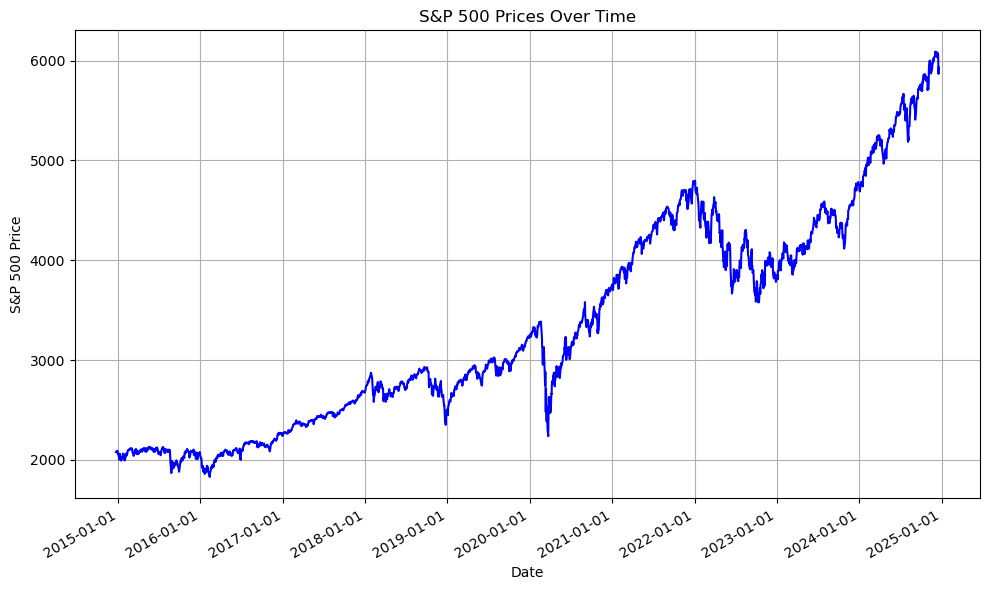

In [1295]:
plt.figure(figsize=(10, 6))
plt.plot(df_index['Date'], df_index['S&P500'], color='b')
plt.title('S&P 500 Prices Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Price')
plt.grid(True)

# Define the date format
date_format = mdates.DateFormatter('%Y-%m-%d')
plt.gca().xaxis.set_major_formatter(date_format)

# Auto-format date labels
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

### Companies CSV

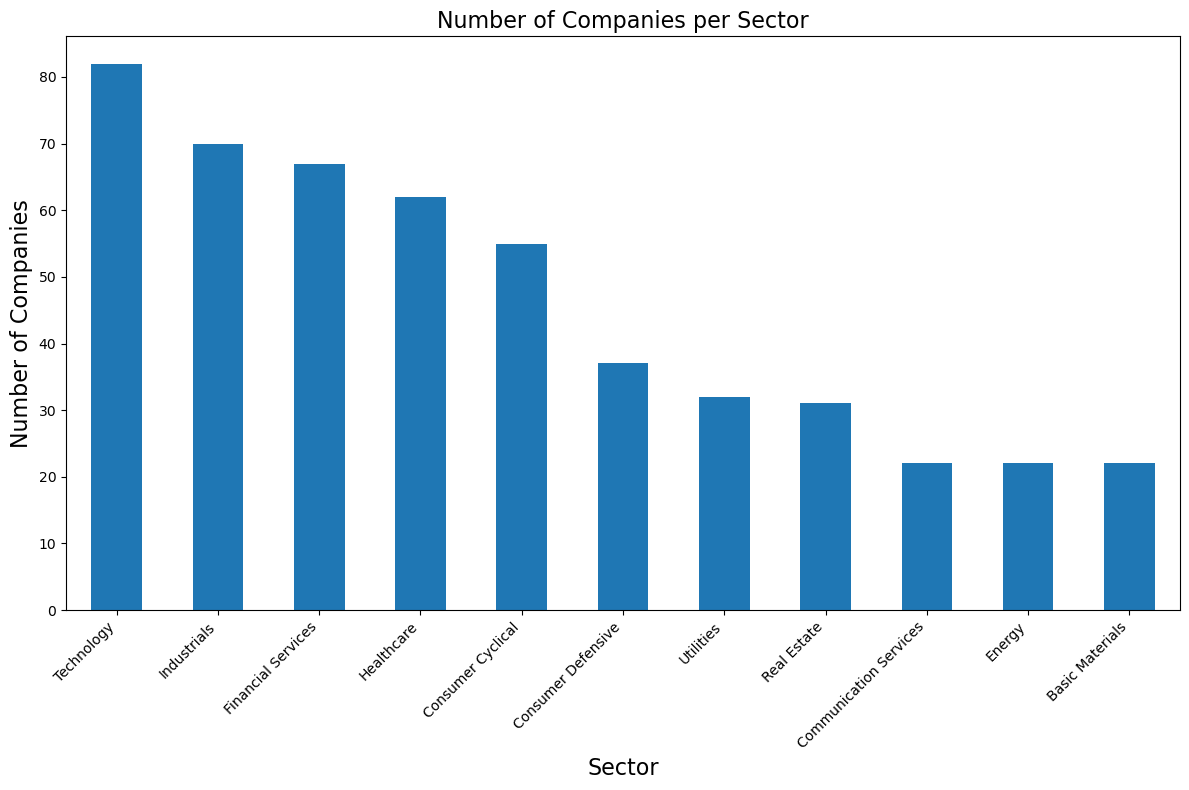

In [1298]:
# Count the number of companies in each sector
sector_counts = df_comp['Sector'].value_counts()

# Plotting
plt.figure(figsize=(12, 8))  # Adjust the size as needed
sector_counts.plot(kind='bar')

plt.title('Number of Companies per Sector', fontsize=16)
plt.xlabel('Sector', fontsize=16)
plt.ylabel('Number of Companies', fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Display the plot
plt.show()


In [1300]:
df_comp.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [1302]:
df_comp['Numshares'] = df_comp['Marketcap'] / df_comp['Currentprice']
df_comp.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight,Numshares
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209,1.511580e+10
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350,2.449000e+10
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401,7.434880e+09
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550,1.051500e+10
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309,1.228580e+10


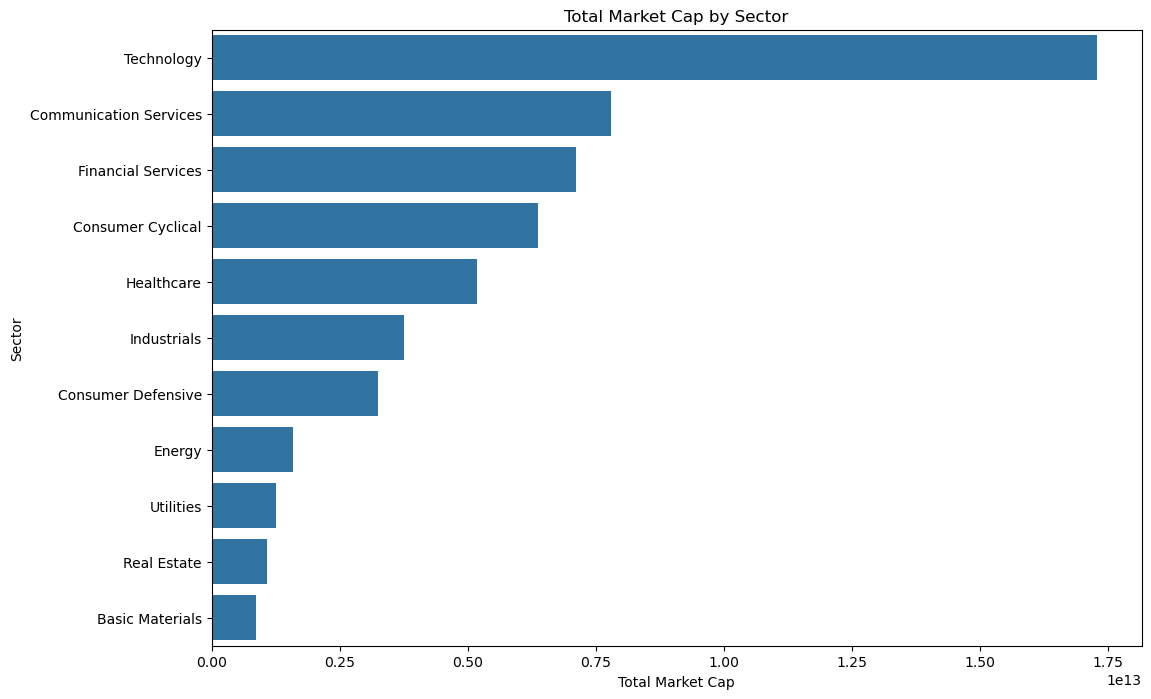

In [1304]:
# Calculate the total Market Cap per Sector
sector_total_marketcap = df_comp.groupby('Sector')['Marketcap'].sum().sort_values(ascending=False)

# Set the plot size
plt.figure(figsize=(12, 8))

# Create the barplot
sns.barplot(x=sector_total_marketcap.values, y=sector_total_marketcap.index)

# Add titles and labels
plt.xlabel('Total Market Cap')
plt.ylabel('Sector')
plt.title('Total Market Cap by Sector')

# Display the plot
plt.show()

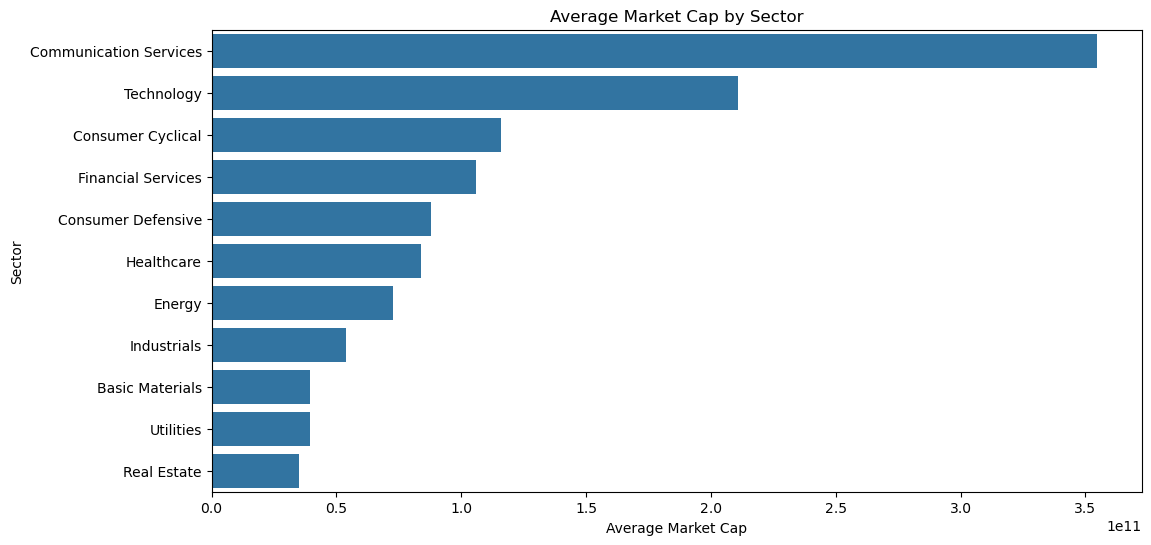

In [1306]:
plt.figure(figsize=(12, 6))
sector_marketcap = df_comp.groupby('Sector')['Marketcap'].mean().sort_values(ascending=False)
sns.barplot(x=sector_marketcap.values, y=sector_marketcap.index)
plt.xlabel('Average Market Cap')
plt.ylabel('Sector')
plt.title('Average Market Cap by Sector')
plt.show()

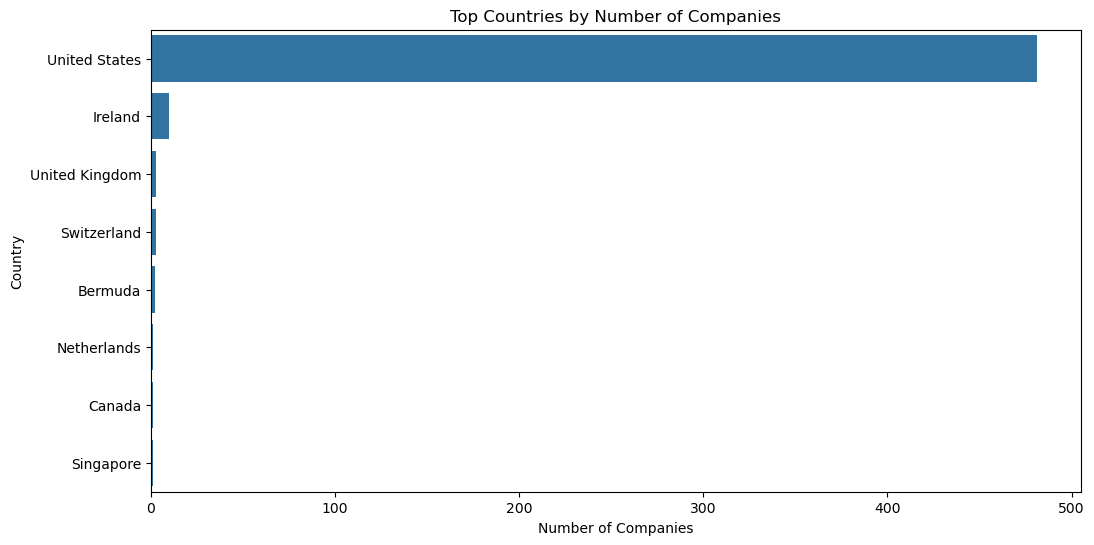

In [1308]:
plt.figure(figsize=(12, 6))
country_counts = df_comp['Country'].value_counts()
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.title('Top Countries by Number of Companies')
plt.show()

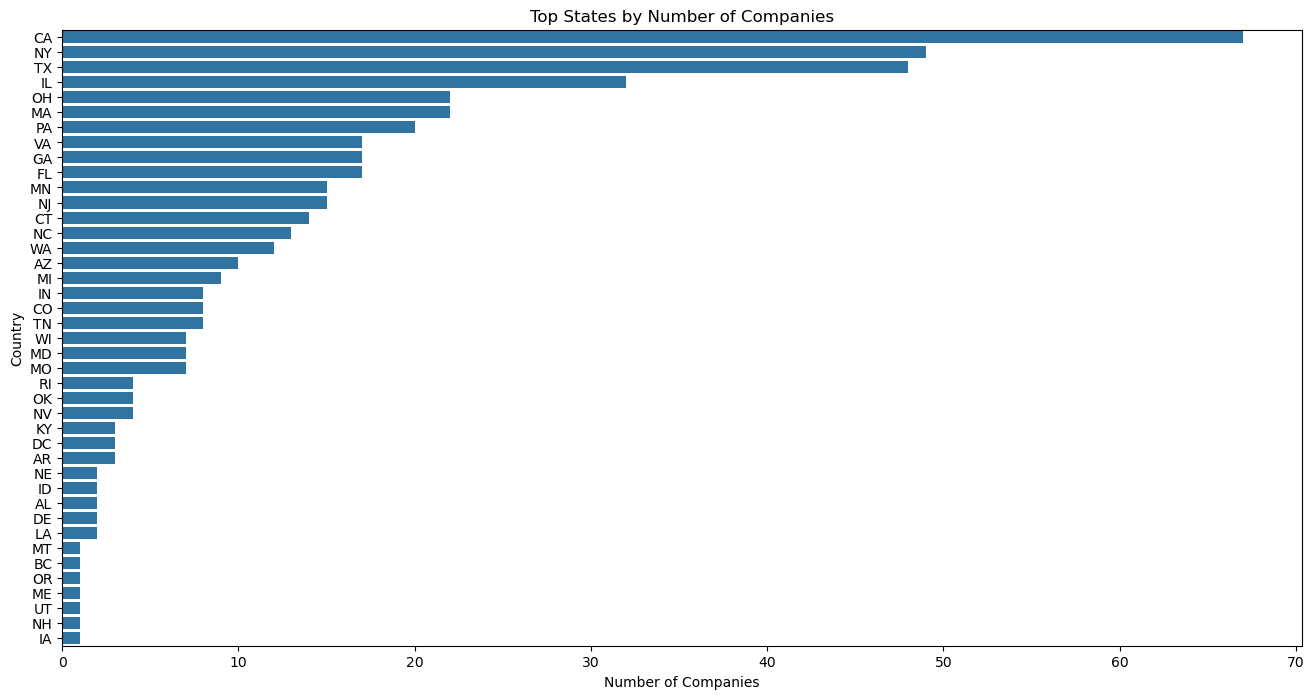

In [1310]:
plt.figure(figsize=(16, 8))
country_counts = df_comp['State'].value_counts()
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.title('Top States by Number of Companies')
plt.show()

### Stocks CSV

In [1313]:
# Convert date to datetime format

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date       datetime64[ns]
 1   Symbol     object        
 2   Adj Close  float64       
 3   Close      float64       
 4   High       float64       
 5   Low        float64       
 6   Open       float64       
 7   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 115.5+ MB


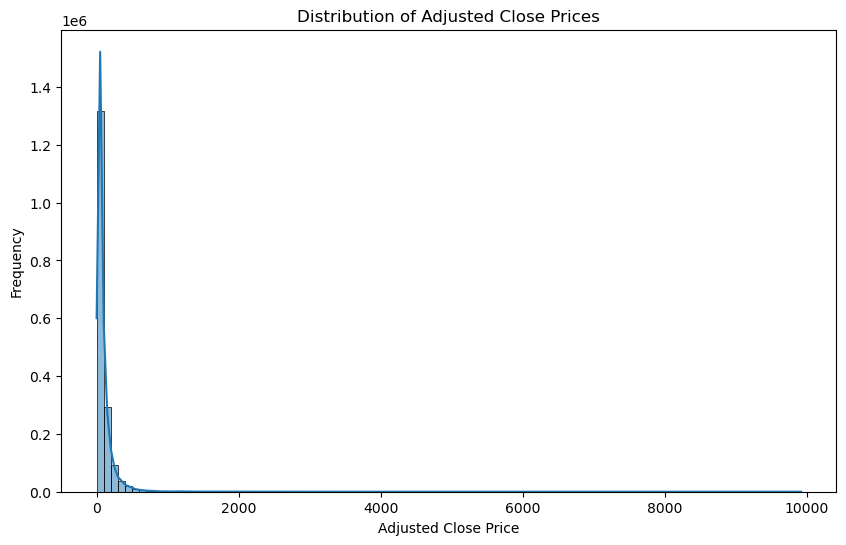

In [1315]:
plt.figure(figsize=(10,6))
sns.histplot(df_stocks['Adj Close'], bins=100, kde=True)
plt.title('Distribution of Adjusted Close Prices')
plt.xlabel('Adjusted Close Price')
plt.ylabel('Frequency')
plt.show()

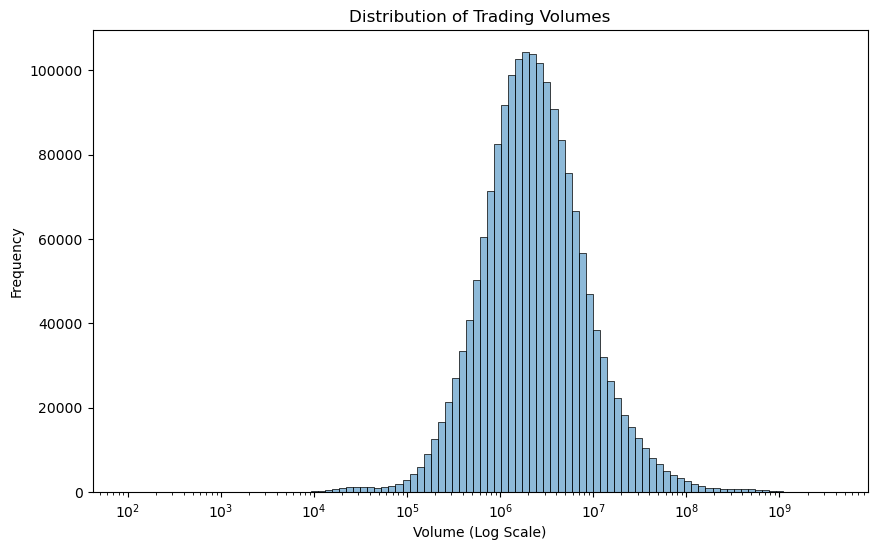

In [1316]:
plt.figure(figsize=(10,6))
sns.histplot(df_stocks['Volume'], bins=100, kde=True, log_scale=True)
plt.title('Distribution of Trading Volumes')
plt.xlabel('Volume (Log Scale)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Handling and Predcition

In [1318]:
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

In [1319]:
df_comp_info = pd.DataFrame(df_comp[['Symbol','Shortname','Marketcap']])
df_comp_info['NumShares'] = df_comp['Marketcap'] / df_comp['Currentprice']
df_comp_info.head()

,Symbol,Shortname,Marketcap,NumShares
0,AAPL,Apple Inc.,3846819807232,1.511580e+10
1,NVDA,NVIDIA Corporation,3298803056640,2.449000e+10
2,MSFT,Microsoft Corporation,3246068596736,7.434880e+09
3,AMZN,"Amazon.com, Inc.",2365033807872,1.051500e+10
4,GOOGL,Alphabet Inc.,2351625142272,1.228580e+10


In [1320]:
# Merge df_comp and df_stocks on the 'Symbol' column
df_merged = pd.merge(
    df_comp[['Symbol', 'Sector']], 
    df_stocks, 
    on='Symbol', 
    how='left'  # or 'left', 'right', 'outer' depending on desired merge strategy
)

# Preview the result
df_merged.head()

,Symbol,Sector,Date,Adj Close,Close,High,Low,Open,Volume
0,AAPL,Technology,2010-01-04,6.447411,7.643214,7.660714,7.585000,7.622500,493729600.0
1,AAPL,Technology,2010-01-05,6.458560,7.656429,7.699643,7.616071,7.664286,601904800.0
2,AAPL,Technology,2010-01-06,6.355828,7.534643,7.686786,7.526786,7.656429,552160000.0
3,AAPL,Technology,2010-01-07,6.344076,7.520714,7.571429,7.466071,7.562500,477131200.0
4,AAPL,Technology,2010-01-08,6.386256,7.570714,7.571429,7.466429,7.510714,447610800.0


In [1321]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 9 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Symbol     object        
 1   Sector     object        
 2   Date       datetime64[ns]
 3   Adj Close  float64       
 4   Close      float64       
 5   High       float64       
 6   Low        float64       
 7   Open       float64       
 8   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 129.9+ MB


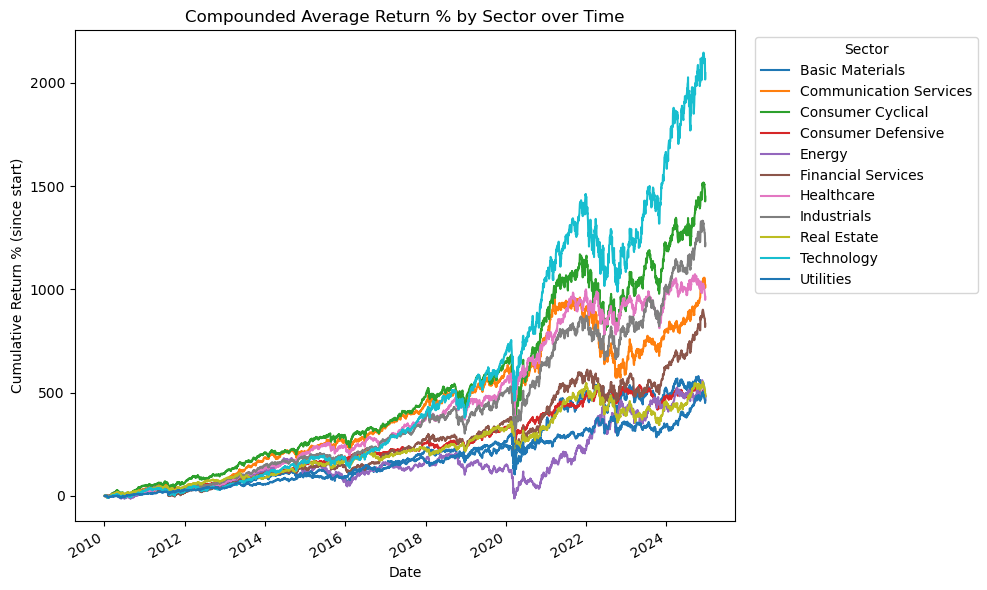

Sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
Date,,,,,,,,,,,
2010-01-05,0.082308,0.249981,1.540832,0.153748,1.044125,0.859370,-0.274757,0.506749,0.556457,-0.098965,-0.818530
2010-01-06,1.788247,-0.523366,1.407180,0.852572,2.115089,0.946539,-0.065958,1.227715,0.379133,-0.217106,-0.417860
2010-01-07,1.437164,-1.081324,2.962051,0.796801,1.835584,2.473705,0.667287,2.045303,1.027688,-0.397025,-0.807906
2010-01-08,2.125546,-1.159024,3.251925,0.376782,2.335394,2.555195,0.595797,2.926248,0.406253,0.369513,-0.813959
2010-01-11,1.802055,-1.155357,3.284686,0.524138,2.045369,2.618875,1.395505,3.737702,0.816224,0.249542,0.288700


In [1322]:
import pandas as pd
import numpy as np

# Let's assume your dataframe is called 'df'
# with columns: Symbol, Sector, Date, Adj Close, Close, High, Low, Open, Volume

# 1) Convert Date to datetime if needed and sort
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged.sort_values(by=['Symbol', 'Date'], inplace=True)

# 2) Compute daily returns for each symbol
#    groupby('Symbol') ensures we calculate pct_change() for each stock individually
df_merged['daily_return'] = df_merged.groupby('Symbol')['Adj Close'].pct_change(fill_method=None)

# 3) Compute average daily return by Sector and Date
#    This yields one average return per sector per day
df_sector_daily = (
    df_merged.groupby(['Date', 'Sector'])['daily_return']
      .mean()
      .reset_index(name='sector_daily_return')
      .dropna(subset=['sector_daily_return'])  # drop rows with NaN returns
)

# 4) Sort by Date so we can do a proper cumulative product
df_sector_daily.sort_values(by=['Sector', 'Date'], inplace=True) 

# 5) For each sector, compound the average daily returns over time
#    We'll pivot so each sector is a column, the index is Date
df_pivot = df_sector_daily.pivot(index='Date', columns='Sector', values='sector_daily_return')

# 6) Calculate the cumulative return over time
#    (1 + daily_return).cumprod() - 1 for each sector
df_cum = ((1 + df_pivot).cumprod() - 1) * 100

plt.figure(figsize=(10, 6))
df_cum.plot(ax=plt.gca())
plt.title("Compounded Average Return % by Sector over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return % (since start)")
plt.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

df_cum.head()

In [1324]:
import numpy as np

# Let's pick the final row of df_cum as the end of our data
end_date = df_cum.index[-1]
start_date = df_cum.index[0]

num_days = (end_date - start_date).days
years = num_days / 365.0

final_cum_returns = df_cum.iloc[-1]  # last row of each sector's cumulative return

# annualized return (assuming daily compounding):
# (1 + total_return)^(1/years) - 1
annualized_returns = (((1 + final_cum_returns) ** (1/years)) - 1) * 100

print("Annualized Returns by Sector (simple average daily returns):")
print(annualized_returns.sort_values(ascending=False))

Annualized Returns by Sector (simple average daily returns):
Sector
Technology                66.433424
Consumer Cyclical         62.634528
Industrials               60.803954
Communication Services    58.861558
Healthcare                58.268551
Financial Services        56.743536
Real Estate               51.324323
Consumer Defensive        51.169753
Basic Materials           51.054639
Energy                    50.777875
Utilities                 50.693249
Name: 2024-12-20 00:00:00, dtype: float64


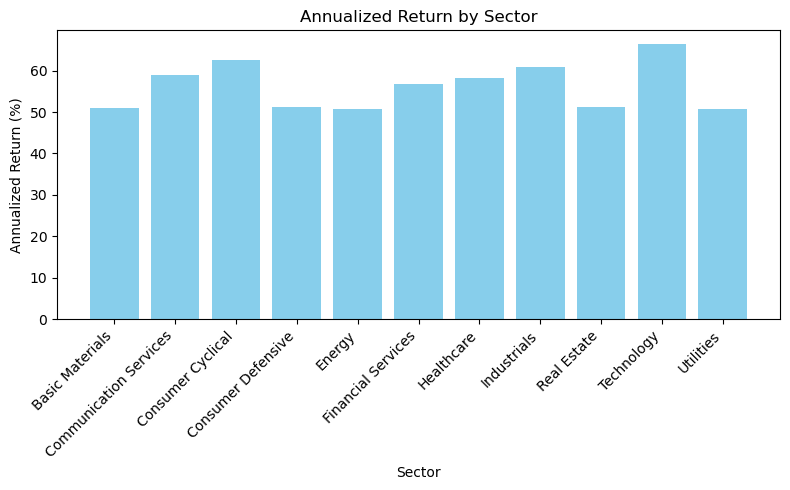

In [1325]:
# Convert the Series to a DataFrame for easier plotting
df_annualized = annualized_returns.reset_index()
df_annualized.columns = ['Sector', 'Annualized_Return']

# Multiply by 100 to get percentage values
df_annualized['Annualized_Return'] = df_annualized['Annualized_Return']

# --------------------------------------------------
# Plot a bar chart of annualized returns by sector
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(df_annualized['Sector'], df_annualized['Annualized_Return'], color='skyblue')
plt.title("Annualized Return by Sector")
plt.xlabel("Sector")
plt.ylabel("Annualized Return (%)")
plt.xticks(rotation=45, ha='right')  # rotate sector names if needed
plt.tight_layout()
plt.show()


In [1326]:
import pandas as pd

# 2. Sort and set index = 'Date' for resampling
df_merged_2 = df_merged

df_merged_2.sort_values(['Symbol', 'Date'], inplace=True)
df_merged_2.set_index('Date', inplace=True)

# 3a. Resample monthly: get last Close of each month per (Symbol, Sector)
monthly_close = (
    df_merged_2
    .groupby(['Symbol','Sector'])['Close']
    .resample('ME')
    .last()        # use last price in the month
    .dropna()
)

# 3b. Compute monthly returns: [ (Price_t - Price_(t-1)) / Price_(t-1) ]
monthly_returns = monthly_close.groupby(level=['Symbol','Sector']).pct_change(fill_method=None) * 100

# 3c. Compute the average monthly return for each Symbol, Sector
avg_monthly_returns = (
    monthly_returns
    .groupby(level=['Symbol','Sector'])
    .mean()
    .reset_index(name='Avg_Monthly_Return')
)


# 4a. Resample yearly: get last Close of each year per (Symbol, Sector)
yearly_close = (
    df_merged
    .groupby(['Symbol','Sector'])['Close']
    .resample('YE')
    .last()
    .dropna()
)

# 4b. Compute yearly returns
yearly_returns = yearly_close.groupby(level=['Symbol','Sector']).pct_change(fill_method=None) * 100

# 4c. Average yearly return
avg_yearly_returns = (
    yearly_returns
    .groupby(level=['Symbol','Sector'])
    .mean()
    .reset_index(name='Avg_Yearly_Return')
)


# 5. Merge average monthly & yearly returns into a single table
df_perf = pd.merge(
    avg_monthly_returns, 
    avg_yearly_returns, 
    on=['Symbol','Sector'],
    how='inner'
)


# 6. Pick top 3 performing stocks per sector by Avg_Yearly_Return
top_3_by_sector = (
    df_perf
    .groupby('Sector', group_keys=False)
    .apply(lambda grp: grp.nlargest(3, 'Avg_Yearly_Return'))
    # or use 'Avg_Monthly_Return' if you prefer
)

# 7. Print the result
print(top_3_by_sector)


    Symbol                  Sector  Avg_Monthly_Return  Avg_Yearly_Return
408    SHW         Basic Materials            1.805460          22.847972
420   STLD         Basic Materials            1.662847          19.023536
310    MLM         Basic Materials            1.373157          16.956838
334   NFLX  Communication Services            3.808850          50.055183
305   META  Communication Services            2.587835          43.987014
453   TTWO  Communication Services            2.114811          28.106225
450   TSLA       Consumer Cyclical            4.730177          99.457392
124    CZR       Consumer Cyclical            3.320343          37.284919
32    AMZN       Consumer Cyclical            2.377772          33.711099
423    STZ      Consumer Defensive            1.770003          22.420157
313   MNST      Consumer Defensive            1.871943          22.415851
107   COST      Consumer Defensive            1.725077          21.785034
443    TPL                  Energy    

/var/folders/db/g3_b7s9n3fvdsyb4pfxmnj200000gn/T/ipykernel_66889/509495530.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.nlargest(3, 'Avg_Yearly_Return'))


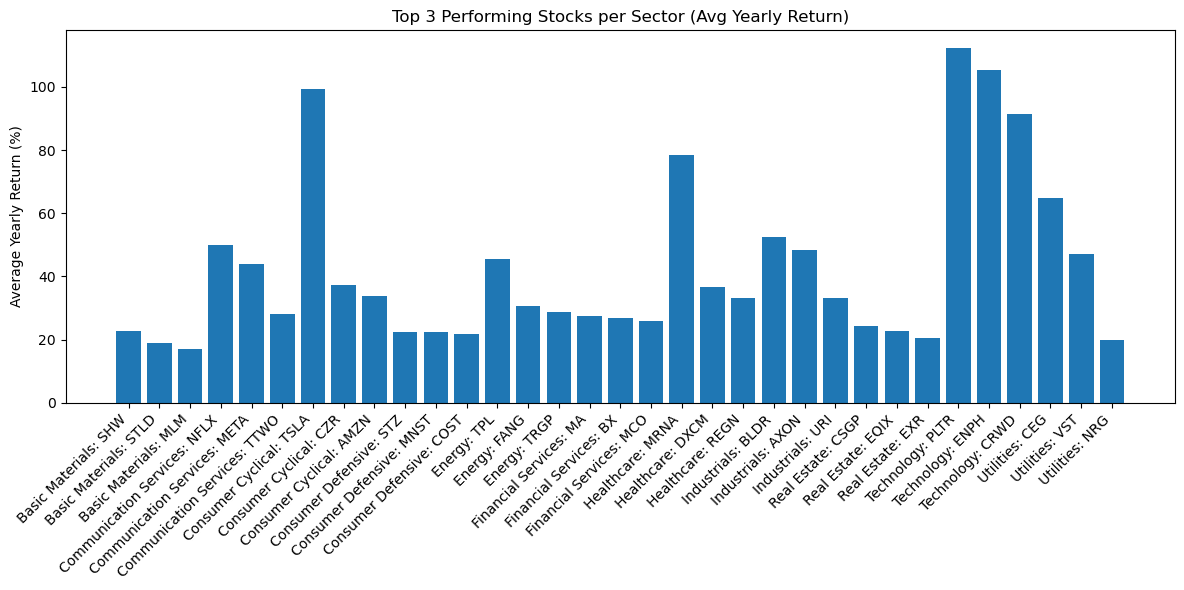

In [1330]:
# Sort globally by Avg_Yearly_Return or by (Sector, Avg_Yearly_Return) if preferred
top_3_by_sector_sorted = top_3_by_sector.sort_values(['Sector', 'Avg_Yearly_Return'], ascending=[True, False])

# Create x-axis labels like "Technology: AAPL", "Technology: MSFT", etc.
labels = top_3_by_sector_sorted.apply(
    lambda row: f"{row['Sector']}: {row['Symbol']}", axis=1
)
returns = top_3_by_sector_sorted['Avg_Yearly_Return']  # in %

x = np.arange(len(labels))  # numeric positions

plt.figure(figsize=(12, 6))
plt.bar(x, returns)
plt.xticks(x, labels, rotation=45, ha='right')
plt.title("Top 3 Performing Stocks per Sector (Avg Yearly Return)")
plt.ylabel("Average Yearly Return (%)")
plt.tight_layout()
plt.show()

# 3. Clustering Stocks

In [1334]:
# # 1) Convert Date to datetime and sort by Symbol, Date
# df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
# df_stocks.sort_values(by=['Symbol', 'Date'], inplace=True)

# # 2) Compute daily returns per Symbol
# df_stocks['daily_return'] = df_stocks.groupby('Symbol')['Adj Close'].pct_change(fill_method=None)

In [1335]:
# df_perf = df_stocks.groupby('Symbol')['daily_return'].agg(
#     avg_daily_return='mean',
#     volatility='std'
# ).reset_index()

In [1336]:
# df_merged = pd.merge(
#     df_perf,      # from df_stocks historical
#     df_comp,      # fundamental snapshot
#     on='Symbol',  
#     how='inner'   # only keep symbols present in both
# )

# df_merged.head()

In [1337]:
# df_cluster = df_merged[['Symbol', 
#                         'avg_daily_return', 
#                         'volatility', 
#                         'Marketcap', 
#                         'Ebitda',
#                         'Revenuegrowth']].copy()

# df_cluster['log_marketcap'] = np.log(df_cluster['Marketcap'].clip(lower=1))
# df_cluster['log_ebitda'] = np.log(df_cluster['Ebitda'].clip(lower=1))

# df_cluster['Revenuegrowth'] = df_cluster['Revenuegrowth'].fillna(df_cluster['Revenuegrowth'].median())
# df_cluster.dropna(inplace=True)

# features = [
#     'avg_daily_return', 
#     'volatility', 
#     'log_marketcap',
#     'log_ebitda',
#     'Revenuegrowth'
# ]

In [1338]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X = scaler.fit_transform(df_cluster[features])

In [1339]:
# from sklearn.cluster import KMeans

# k = 4  # example
# kmeans = KMeans(n_clusters=k, random_state=42)
# labels = kmeans.fit_predict(X)

# df_cluster['Cluster'] = labels

In [1340]:
# df_cluster = pd.merge(
#     df_cluster, 
#     df_merged[['Symbol','Sector','Industry']], 
#     on='Symbol', 
#     how='left'
# )

In [1341]:
# composition = df_cluster.groupby(['Cluster','Sector'])['Symbol'].count().reset_index()
# composition.rename(columns={'Symbol':'Count'}, inplace=True)
# print(composition)

In [1342]:
# sns.scatterplot(
#     data=df_cluster, 
#     x='avg_daily_return', 
#     y='volatility', 
#     hue='Cluster'
# )
# plt.title("Clusters in Return-Volatility Space")
# plt.show()

In [1343]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler

# # ---------------------------
# # (A) PREP: Merged DataFrame
# # ---------------------------
# # Assume you have already:
# # - Merged df_stocks + df_comp into df_merged
# # - Computed historical performance metrics like avg_daily_return, volatility
# # - Created df_cluster with columns = 
# #     ['Symbol', 'Sector', 'avg_daily_return', 'volatility', 'Marketcap', 'Ebitda', 'Revenuegrowth', ...]
# # - Log-transformed & handled NaNs

# features = [
#     'avg_daily_return', 
#     'volatility', 
#     'log_marketcap',
#     'log_ebitda',
#     'Revenuegrowth'
# ]

# # Scale
# scaler = StandardScaler()
# X = scaler.fit_transform(df_cluster[features])

# # ---------------------------
# # (B) CLUSTER
# # ---------------------------
# k = 4  # or however many clusters you want
# kmeans = KMeans(n_clusters=k, random_state=42)
# labels = kmeans.fit_predict(X)

# df_cluster['Cluster'] = labels

# # ---------------------------
# # (C) SECTOR COMPOSITION
# # ---------------------------
# composition = (
#     df_cluster.groupby(['Cluster','Sector'])['Symbol']
#     .count()
#     .reset_index()
#     .rename(columns={'Symbol':'Count'})
# )

# # Create pivot for stacked bar
# pivot_comp = composition.pivot(index='Cluster', columns='Sector', values='Count').fillna(0)

# # Plot stacked bar of sector composition
# plt.figure(figsize=(10,6))
# pivot_comp.plot(kind='bar', stacked=True, ax=plt.gca())
# plt.title("Sector Composition by Cluster")
# plt.xlabel("Cluster")
# plt.ylabel("Number of Stocks")
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# # ---------------------------
# # (D) CLUSTER PROFILES (feature means)
# # ---------------------------
# cluster_profiles = (
#     df_cluster
#     .groupby('Cluster')[features]
#     .mean()  # or median()
# )

# print(cluster_profiles)


# 4. Time-series forecast

In [1348]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# 1) Check for null values
# -----------------------------

print("Null values per column:\n", df_stocks.isnull().sum())

Null values per column:
 Date              0
Symbol            0
Adj Close    100475
Close        100475
High         100475
Low          100475
Open         100475
Volume       100475
dtype: int64


In [1349]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# A) Setup: df_comp has columns like ['Symbol', 'Marketcap', 'weight'] for 2024-12-20
#           df_stocks has ['Symbol', 'Date', 'Adj Close'] for a time series
# ------------------------------------------------------------------------------
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
reference_date = pd.to_datetime('2024-12-20')

# ------------------------------------------------------------------------------
# 1) Extract the row from df_stocks where Date == 2024-12-20 for each Symbol
# ------------------------------------------------------------------------------
df_refday = df_stocks[df_stocks['Date'] == reference_date].copy()

# Merge the final day Marketcap & weight from df_comp with the final day AdjClose
df_comp_ref = pd.merge(
    df_comp,           # columns: Symbol, Marketcap, weight, etc.
    df_refday[['Symbol', 'Adj Close']], 
    on='Symbol', 
    how='inner'
)
df_comp_ref.rename(columns={'Adj Close': 'AdjClose_final'}, inplace=True)

# ------------------------------------------------------------------------------
# 2) Compute 'shares' from final day market cap
# ------------------------------------------------------------------------------
# shares_i = MarketCap_i(2024-12-20) / AdjClose_i(2024-12-20)
df_comp_ref['Shares'] = df_comp_ref['Marketcap'] / df_comp_ref['AdjClose_final']

# ------------------------------------------------------------------------------
# 3) Merge 'Shares' into the entire time-series
# ------------------------------------------------------------------------------
df_stocks_shares = pd.merge(
    df_stocks,
    df_comp_ref[['Symbol', 'Shares']],
    on='Symbol',
    how='inner'
)

# ------------------------------------------------------------------------------
# 4) Back-propagate market cap => 'BackpropMarketCap' = Shares * AdjClose(t)
# ------------------------------------------------------------------------------
df_stocks_shares['BackpropMarketCap'] = (
    df_stocks_shares['Shares'] * df_stocks_shares['Adj Close']
)

# ------------------------------------------------------------------------------
# 5) Aggregate by Date to get total BackpropMarketCap (if you want a "sector" or "index")
# ------------------------------------------------------------------------------
df_daily_total = (
    df_stocks_shares
    .groupby('Date', as_index=False)['BackpropMarketCap']
    .sum()
    .rename(columns={'BackpropMarketCap': 'TotalBackpropMarketCap'})
)

# Merge back to get the daily total for each Symbol
df_stocks_shares = pd.merge(
    df_stocks_shares, 
    df_daily_total, 
    on='Date', 
    how='left'
)

# ------------------------------------------------------------------------------
# 6) Compute daily back-propagated weight => BackpropMarketCap_i / total
# ------------------------------------------------------------------------------
df_stocks_shares['BackpropWeight'] = (
    df_stocks_shares['BackpropMarketCap'] / df_stocks_shares['TotalBackpropMarketCap']
)

df_stocks_shares.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,Shares,BackpropMarketCap,TotalBackpropMarketCap,BackpropWeight
0,2010-01-04,MMM,44.016731,69.414719,69.774246,69.122070,69.473244,3640265.0,5.445590e+08,2.396971e+10,6.132863e+12,0.003908
1,2010-01-05,MMM,43.741032,68.979935,69.590302,68.311035,69.230766,3405012.0,5.445590e+08,2.381957e+10,6.157496e+12,0.003868
2,2010-01-06,MMM,44.361343,69.958191,70.735786,69.824417,70.133781,6301126.0,5.445590e+08,2.415737e+10,6.155330e+12,0.003925
3,2010-01-07,MMM,44.393166,70.008362,70.033447,68.662209,69.665550,5346240.0,5.445590e+08,2.417470e+10,6.168751e+12,0.003919
4,2010-01-08,MMM,44.705967,70.501671,70.501671,69.648827,69.974915,4073337.0,5.445590e+08,2.434503e+10,6.185802e+12,0.003936


In [1350]:
df_stocks = df_stocks_shares.drop(['Shares','Close','High','Low','Open','Volume','TotalBackpropMarketCap'],axis=1)
df_stocks.head()

,Date,Symbol,Adj Close,BackpropMarketCap,BackpropWeight
0,2010-01-04,MMM,44.016731,2.396971e+10,0.003908
1,2010-01-05,MMM,43.741032,2.381957e+10,0.003868
2,2010-01-06,MMM,44.361343,2.415737e+10,0.003925
3,2010-01-07,MMM,44.393166,2.417470e+10,0.003919
4,2010-01-08,MMM,44.705967,2.434503e+10,0.003936


In [1351]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# # -----------------------------
# # 1) Check for null values
# # -----------------------------
# print("Null values per column:\n", df_stocks.isnull().sum())

# # -----------------------------
# # 2) Ensure 'Date' is in datetime format
# # -----------------------------
# df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# # -----------------------------
# # 3) Filter the dataset for AAPL
# # -----------------------------
# df_AAPL = df_stocks[df_stocks['Symbol'] == 'AAPL'].copy()

# # -----------------------------
# # 4) Sort by Date (important for time series)
# # -----------------------------
# df_AAPL.sort_values(by='Date', inplace=True)
# df_AAPL.reset_index(drop=True, inplace=True)

# # -----------------------------
# # 5) Prepare the data for LSTM
# # -----------------------------
# # Extract only the 'Adj Close' column
# closing_prices = df_AAPL[['Adj Close']].values

# # Scale the data to [0, 1] for better LSTM performance
# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_data = scaler.fit_transform(closing_prices)

# # Decide how much of the data will be used for training
# training_size = int(len(scaled_data) * 0.8)
# train_data = scaled_data[:training_size]
# test_data = scaled_data[training_size:]  # scaled test portion

# # Window size (look-back period)
# window_size = 60

# x_train = []
# y_train = []

# # Build the sequences for LSTM
# for i in range(window_size, len(train_data)):
#     x_train.append(train_data[i - window_size:i, 0])  # 60 timesteps
#     y_train.append(train_data[i, 0])                 # target is the next timestep

# x_train = np.array(x_train)
# y_train = np.array(y_train)

# # Reshape x_train to be [samples, timesteps, features]
# x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# # -----------------------------
# # 6) Build the LSTM model
# # -----------------------------
# model = Sequential()
# model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
# model.add(LSTM(50, return_sequences=False))
# model.add(Dense(25))
# model.add(Dense(1))  # Final layer: predicting a single price

# model.compile(optimizer='adam', loss='mean_squared_error')

# # -----------------------------
# # 7) (Re)Train the model
# # -----------------------------
# model.fit(x_train, y_train, batch_size=16, epochs=10)

# # -----------------------------
# # 8) Prepare test data
# # -----------------------------
# # We overlap by 'window_size' so the model can have the required look-back for the test set
# total_test_data = scaled_data[training_size - window_size:]  
# x_test = []
# y_test = closing_prices[training_size:]  # ground truth (unscaled) for evaluation

# for i in range(window_size, len(total_test_data)):
#     x_test.append(total_test_data[i - window_size:i, 0])

# x_test = np.array(x_test)
# x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# # -----------------------------
# # 9) Make predictions on the test set
# # -----------------------------
# predictions = model.predict(x_test)

# # Invert scaling to get actual price values
# predictions = scaler.inverse_transform(predictions)

# # -----------------------------
# # 10) Evaluate performance
# # -----------------------------
# rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
# print(f"Test RMSE: {rmse}")

# # ---------------------------------
# # 11) Plotting results - (Test Set)
# # ---------------------------------
# plt.figure(figsize=(12, 6))
# plt.plot(df_AAPL['Date'][training_size:], y_test, label='Actual Price', color='blue')
# plt.plot(df_AAPL['Date'][training_size:], predictions, label='Predicted Price', color='red')
# plt.title('AAPL Stock Price Prediction (Test Set)')
# plt.xlabel('Date')
# plt.ylabel('Adjusted Close Price')
# plt.legend()
# plt.show()

# # ---------------------------------
# # 12) Plotting the entire dataset + predictions
# # ---------------------------------
# plt.figure(figsize=(12, 6))
# plt.plot(df_AAPL['Date'], df_AAPL['Adj Close'], label='All Actual Prices', color='blue')
# plt.plot(df_AAPL['Date'][training_size:], predictions, label='Predicted Prices (Test Portion)', color='red')
# plt.axvline(df_AAPL['Date'][training_size], color='green', linestyle='--', label='Train/Test Split')
# plt.title('AAPL Stock Price - Entire Dataset with Predictions')
# plt.xlabel('Date')
# plt.ylabel('Adjusted Close Price')
# plt.legend()
# plt.show()

# # =========================================================
# #              FORECAST THE NEXT YEAR
# # =========================================================

# # (A) We will do a rolling forecast for ~252 trading days 
# #     or 365 calendar days. Adjust as desired.
# future_days = 356  # approximate # of trading days in 1 year

# # (B) Start with the last 'window_size' days from *all* scaled_data
# last_60_days = scaled_data[-window_size:].copy()

# future_predictions_scaled = []
# current_batch = last_60_days.reshape((1, window_size, 1))

# for _ in range(future_days):
#     # 1) Predict the next day (scaled)
#     next_pred_scaled = model.predict(current_batch)[0]  # shape -> (1,1)
    
#     # 2) Append prediction to list
#     future_predictions_scaled.append(next_pred_scaled)
    
#     # 3) Update current_batch by removing the oldest day and adding the new prediction
#     current_batch = np.append(current_batch[:, 1:, :], [[next_pred_scaled]], axis=1)

# # (C) Inverse transform the predictions
# future_predictions_scaled = np.array(future_predictions_scaled)
# future_predictions = scaler.inverse_transform(future_predictions_scaled)

# # (D) Build a date range for the forecast
# last_date = df_AAPL['Date'].iloc[-1]
# # If you prefer business days for the forecast, use freq='B'
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
#                              periods=future_days, 
#                              freq='B')  

# df_forecast = pd.DataFrame({
#     'Date': future_dates,
#     'Adj Close Forecast': future_predictions.ravel()
# })

# print("\nSample Future Forecast:")
# print(df_forecast.head())
# print(df_forecast.tail())

# # (E) Plot the forecast vs. historical data
# # Option 1: Plot on a separate figure
# plt.figure(figsize=(12, 6))
# plt.plot(df_AAPL['Date'], df_AAPL['Adj Close'], label='Historical', color='blue')
# plt.plot(df_forecast['Date'], df_forecast['Adj Close Forecast'], label='Future Forecast (1 year)', color='orange')
# plt.title("AAPL Stock Price Forecast for Next Year")
# plt.xlabel("Date")
# plt.ylabel("Adjusted Close Price")
# plt.legend()
# plt.show()

# # Option 2: Combine them into one DataFrame for convenience
# # We'll rename the forecast column to 'Adj Close' so we can just concatenate easily
# df_forecast_for_plot = df_forecast.rename(columns={'Adj Close Forecast': 'Adj Close'})
# df_all = pd.concat([df_AAPL[['Date', 'Adj Close']], df_forecast_for_plot])

# plt.figure(figsize=(12, 6))
# plt.plot(df_all['Date'], df_all['Adj Close'], label='Historical + Forecast', color='blue')
# plt.axvline(last_date, color='red', linestyle='--', label='Forecast Start')
# plt.title("AAPL Stock Price: Historical & 1-Year Forecast")
# plt.xlabel("Date")
# plt.ylabel("Adjusted Close Price")
# plt.legend()
# plt.show()


In [1352]:
df_stocks.head()

,Date,Symbol,Adj Close,BackpropMarketCap,BackpropWeight
0,2010-01-04,MMM,44.016731,2.396971e+10,0.003908
1,2010-01-05,MMM,43.741032,2.381957e+10,0.003868
2,2010-01-06,MMM,44.361343,2.415737e+10,0.003925
3,2010-01-07,MMM,44.393166,2.417470e+10,0.003919
4,2010-01-08,MMM,44.705967,2.434503e+10,0.003936


In [1353]:
df_comp.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight,Numshares
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209,1.511580e+10
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350,2.449000e+10
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401,7.434880e+09
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550,1.051500e+10
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309,1.228580e+10


In [1355]:
# Option A: Drop old sector column before merge
df_stocks.drop(columns='Sector', inplace=True, errors='ignore')

df_stocks = pd.merge(
    df_stocks,
    df_comp[['Symbol', 'Sector']],
    on='Symbol',
    how='left'
)

df_stocks.head()

,Date,Symbol,Adj Close,BackpropMarketCap,BackpropWeight,Sector
0,2010-01-04,MMM,44.016731,2.396971e+10,0.003908,Industrials
1,2010-01-05,MMM,43.741032,2.381957e+10,0.003868,Industrials
2,2010-01-06,MMM,44.361343,2.415737e+10,0.003925,Industrials
3,2010-01-07,MMM,44.393166,2.417470e+10,0.003919,Industrials
4,2010-01-08,MMM,44.705967,2.434503e+10,0.003936,Industrials


In [1367]:
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 6 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Date               datetime64[ns]
 1   Symbol             object        
 2   Adj Close          float64       
 3   BackpropMarketCap  float64       
 4   BackpropWeight     float64       
 5   Sector             object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 86.6+ MB


## Handling Null Values for Close Price

In [1375]:
print("Null values per column:\n", df_stocks.isnull().sum())

Null values per column:
 Date                      0
Symbol                    0
Adj Close            100475
BackpropMarketCap    100475
BackpropWeight       100475
Sector                    0
dtype: int64


In [1377]:
df_stocks_forecast = df_stocks

In [1381]:
import pandas as pd

# 1) Identify the last date in the dataset
last_date = df_stocks['Date'].max()

# 2) Filter the DataFrame for that last date
df_last_date = df_stocks[df_stocks['Date'] == last_date].copy()

# 3) Define which columns represent actual stock data 
#    (everything except 'Date' and 'Symbol')
stock_data_cols = [col for col in df_stocks.columns if col not in ['Date', 'Symbol']]

# 4) Check if all those stock-data columns are NaN for each row
mask_all_null = df_last_date[stock_data_cols].isna().all(axis=1)

# 5) Extract the rows (and thus symbols) where all stock-data columns are null
df_removed_stocks = df_last_date[mask_all_null]

removed_symbols = df_removed_stocks['Symbol'].unique()

print("Stocks with all-null data on the last date (likely removed):")
print(removed_symbols)

Stocks with all-null data on the last date (likely removed):
[]


In [1383]:
# df_stocks_forecast = df_stocks.drop(['Close', 'High', 'Low', 'Open', 'Volume'], axis = 1)
df_stocks_forecast.head()

,Date,Symbol,Adj Close,BackpropMarketCap,BackpropWeight,Sector
0,2010-01-04,MMM,44.016731,2.396971e+10,0.003908,Industrials
1,2010-01-05,MMM,43.741032,2.381957e+10,0.003868,Industrials
2,2010-01-06,MMM,44.361343,2.415737e+10,0.003925,Industrials
3,2010-01-07,MMM,44.393166,2.417470e+10,0.003919,Industrials
4,2010-01-08,MMM,44.705967,2.434503e+10,0.003936,Industrials


In [1385]:
print("Null values per column:\n", df_stocks_forecast.isnull().sum())

Null values per column:
 Date                      0
Symbol                    0
Adj Close            100475
BackpropMarketCap    100475
BackpropWeight       100475
Sector                    0
dtype: int64


In [1387]:
def nulls_are_contiguous_from_start(df_symbol, col='Adj Close'):
    """
    Return True if, for `col`, the data is null from the earliest date
    up to some point, and then entirely non-null afterwards.
    """
    # Sort by Date in case it's not sorted
    df_symbol = df_symbol.sort_values('Date')
    
    # Boolean mask of is-null for the chosen column
    null_mask = df_symbol[col].isnull()
    # Boolean mask of not-null
    not_null_mask = ~null_mask
    
    # If everything is null, it's technically contiguous from start 
    # (though no real data afterward).
    if null_mask.all():
        return True
    
    # If there's at least one valid entry, find the first valid date
    first_not_null_idx = not_null_mask.idxmax()  
    # This gives the first row index in df_symbol where 'col' is non-null.
    first_not_null_date = df_symbol.loc[first_not_null_idx, 'Date']
    
    # Check that everything BEFORE this date is null:
    before_df = df_symbol[df_symbol['Date'] < first_not_null_date]
    if not before_df.empty and not before_df[col].isnull().all():
        # There's at least one non-null in the "before" portion => random distribution
        return False
    
    # Check that everything FROM this date onward is not null:
    after_df = df_symbol[df_symbol['Date'] >= first_not_null_date]
    if after_df[col].isnull().any():
        # There's at least one null after we said we'd have only valid data => random
        return False
    
    # If both checks pass, it's contiguous from the start
    return True

# Now we can apply this to each symbol
contiguous_symbols = []
random_symbols = []

for sym, group in df_stocks_forecast.groupby('Symbol'):
    if nulls_are_contiguous_from_start(group, col='Adj Close'):
        contiguous_symbols.append(sym)
    else:
        random_symbols.append(sym)

print("\nSymbols that have contiguous nulls from the start, then all valid data:")
print(contiguous_symbols)

print("\nSymbols that have random (or partial) null distributions (not strictly from the start):")
print(random_symbols)



Symbols that have contiguous nulls from the start, then all valid data:
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMTM', 'AMZN', 'ANET', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APTV', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CE', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVS', 'CVX', 'CZR', 'D', 'DAL', 'DAY', '

In [1388]:
def first_valid_date(symbol_df, col='Adj Close'):
    # Ensure chronological order
    symbol_df = symbol_df.sort_values('Date')
    null_mask = symbol_df[col].isnull()
    not_null_mask = ~null_mask

    if not not_null_mask.any():
        # Entirely null for this symbol
        return None

    first_not_null_idx = not_null_mask.idxmax()  # index of first non-null
    return symbol_df.loc[first_not_null_idx, 'Date']

# 1) Groupby, apply the function
first_valid_dates_series = df_stocks.groupby('Symbol').apply(lambda g: first_valid_date(g, col='Adj Close'))

# 2) Convert to DataFrame
first_valid_dates_df = first_valid_dates_series.to_frame(name='First_Valid_Date').reset_index()

# Now we have columns: ['Symbol', 'First_Valid_Date']
print(first_valid_dates_df.head())

# 3) The earliest date at which all symbols have no nulls
all_symbols_start = first_valid_dates_df['First_Valid_Date'].max()
print("Earliest date with no nulls for all symbols:", all_symbols_start)


  Symbol First_Valid_Date
0      A       2010-01-04
1   AAPL       2010-01-04
2   ABBV       2013-01-02
3   ABNB       2020-12-10
4    ABT       2010-01-04
Earliest date with no nulls for all symbols: 2024-09-24 00:00:00


/var/folders/db/g3_b7s9n3fvdsyb4pfxmnj200000gn/T/ipykernel_66889/528423457.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_valid_dates_series = df_stocks.groupby('Symbol').apply(lambda g: first_valid_date(g, col='Adj Close'))


In [1390]:
import pandas as pd

# 1) Ensure the DataFrame is sorted and 'Date' is in datetime format
df_stocks_forecast['Date'] = pd.to_datetime(df_stocks_forecast['Date'])

# 2) Find the total number of unique symbols
all_symbols = df_stocks_forecast['Symbol'].unique()
total_symbols = len(all_symbols)
ninety_percent_symbols = total_symbols * 0.9

print(f"Total symbols in dataset: {total_symbols}")
print(f"90% of the symbols: {ninety_percent_symbols}")

# 3) Filter for non-null data in the chosen column (e.g. 'Adj Close')
df_valid = df_stocks_forecast.dropna(subset=['Adj Close'])

# 4) For each Date, count how many distinct Symbols have valid 'Adj Close'
count_by_date = (
    df_valid
    .groupby('Date')['Symbol']
    .nunique()  # number of unique Symbols on that date
    .sort_index()  # ensures chronological order by date
)

# 5) Find the earliest date where distinct symbol count > eighty_percent_symbols
dates_with_majority = count_by_date[count_by_date > ninety_percent_symbols]
if not dates_with_majority.empty:
    earliest_date_with_majority = dates_with_majority.index.min()
    print("\nEarliest date when more than 80% the stocks are in the dataset:")
    print(earliest_date_with_majority)
else:
    print("\nNo date found where more than 80% the stocks have valid data.")


Total symbols in dataset: 502
90% of the symbols: 451.8

Earliest date when more than 80% the stocks are in the dataset:
2012-06-29 00:00:00


Total symbols in dataset: 502
Earliest date when more than 85% of the stocks have valid data: 2010-01-04 00:00:00
Earliest date when more than 90% of the stocks have valid data: 2012-06-29 00:00:00
Earliest date when more than 95% of the stocks have valid data: 2016-10-05 00:00:00
Earliest date when more than 99% of the stocks have valid data: 2023-05-04 00:00:00


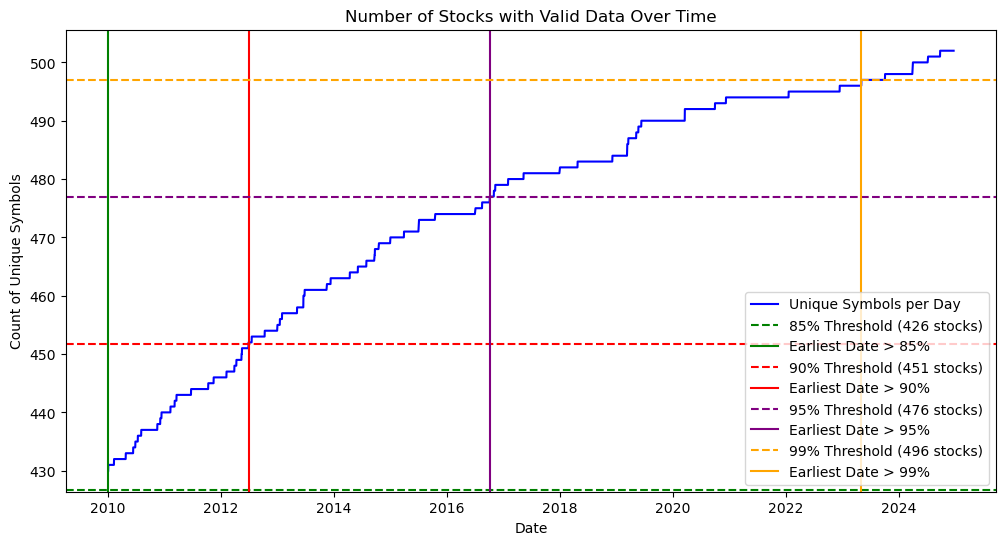

In [1393]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# 1) Ensure 'Date' is datetime and the DataFrame is sorted
# ----------------------------------------------------------------------------
df_stocks_forecast['Date'] = pd.to_datetime(df_stocks_forecast['Date'])
df_stocks_forecast.sort_values(by='Date', inplace=True)

# ----------------------------------------------------------------------------
# 2) Count total unique symbols
# ----------------------------------------------------------------------------
all_symbols = df_stocks_forecast['Symbol'].unique()
total_symbols = len(all_symbols)
print(f"Total symbols in dataset: {total_symbols}")

# ----------------------------------------------------------------------------
# 3) Filter for non-null 'Adj Close' and count unique symbols per date
# ----------------------------------------------------------------------------
df_valid = df_stocks_forecast.dropna(subset=['Adj Close'])
count_by_date = (
    df_valid
    .groupby('Date')['Symbol']
    .nunique()
    .sort_index()
)

# ----------------------------------------------------------------------------
# 4) Define coverage thresholds as percentages
# ----------------------------------------------------------------------------
coverage_levels = [0.85, 0.90, 0.95, 0.99]
coverage_dict = {}

for level in coverage_levels:
    threshold_count = total_symbols * level
    coverage_dict[level] = threshold_count
    
    # Find earliest date with symbol count > threshold_count
    coverage_dates = count_by_date[count_by_date > threshold_count]
    if not coverage_dates.empty:
        earliest_date = coverage_dates.index.min()
        print(f"Earliest date when more than {int(level*100)}% of the stocks have valid data: {earliest_date}")
        coverage_dict[level] = (threshold_count, earliest_date)
    else:
        print(f"No date found where more than {int(level*100)}% of the stocks have valid data.")
        coverage_dict[level] = (threshold_count, None)

# ----------------------------------------------------------------------------
# 5) Plot the line for unique symbols over time
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(count_by_date.index, count_by_date.values, label='Unique Symbols per Day', color='blue')

# ----------------------------------------------------------------------------
# 6) For each threshold, add a horizontal line & possibly a vertical line
# ----------------------------------------------------------------------------
colors = {0.85: 'green', 0.90: 'red', 0.95: 'purple', 0.99: 'orange'}

for level, (thresh_value, date_val) in coverage_dict.items():
    # Horizontal line at coverage threshold
    plt.axhline(y=thresh_value, color=colors[level], linestyle='--',
                label=f'{int(level*100)}% Threshold ({int(thresh_value)} stocks)')

    # If we found a valid earliest date, plot a vertical line
    if date_val is not None:
        plt.axvline(x=date_val, color=colors[level], linestyle='-',
                    label=f'Earliest Date > {int(level*100)}%')

# ----------------------------------------------------------------------------
# 7) Final formatting
# ----------------------------------------------------------------------------
plt.title('Number of Stocks with Valid Data Over Time')
plt.xlabel('Date')
plt.ylabel('Count of Unique Symbols')
plt.legend()
plt.show()


## Forecast

### Forecast 1

In [1397]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# #------------------------------------------------------------------------------
# # 1) Known coverage thresholds (from your prior analysis)
# #    For demonstration, we store them in a dict for clarity:
# #------------------------------------------------------------------------------
# coverage_thresholds = {
#     '90%': pd.to_datetime('2012-06-29'),
#     '95%': pd.to_datetime('2016-10-05'),
#     '100%': pd.to_datetime('2023-05-04')
# }

# #------------------------------------------------------------------------------
# # 2) Check nulls, ensure 'Date' is datetime, sort by Symbol & Date
# #------------------------------------------------------------------------------
# print("Null values per column:\n", df_stocks_forecast.isnull().sum())
# df_stocks_forecast['Date'] = pd.to_datetime(df_stocks_forecast['Date'])
# df_stocks_forecast.sort_values(by=['Symbol', 'Date'], inplace=True)
# df_stocks_forecast.reset_index(drop=True, inplace=True)

# #------------------------------------------------------------------------------
# # 3) Calculate daily % change for each Symbol (Adj Close)
# #------------------------------------------------------------------------------
# df_stocks_forecast['Pct_change_AdjClose'] = (
#     df_stocks_forecast.groupby('Symbol')['Adj Close'].pct_change()
# )

# #------------------------------------------------------------------------------
# # 4) Function to create a "clean" DataFrame for a given coverage date
# #    Steps:
# #    - Filter the data from coverage_date onward
# #    - Drop symbols that are not valid (i.e., contain any NaN in that period)
# #    - Group by Sector & Date to get average daily % change
# #    - Compute Cumulative_return
# #------------------------------------------------------------------------------
# def prepare_data_for_coverage(df, coverage_date):
#     # 1) Filter from coverage_date onward
#     df_filtered = df[df['Date'] >= coverage_date].copy()
    
#     # 2) Identify & drop symbols that have null Pct_change_AdjClose in this range
#     #    Because we want only fully valid data from coverage_date onward.
#     #    We'll do this by grouping each symbol's rows and checking for any NaNs.
    
#     # Find symbols that have any NaN in 'Pct_change_AdjClose' from coverage_date onward
#     symbols_with_nan = (
#         df_filtered[df_filtered['Pct_change_AdjClose'].isna()]
#         ['Symbol']
#         .unique()
#     )
    
#     # Drop those symbols entirely
#     df_filtered = df_filtered[~df_filtered['Symbol'].isin(symbols_with_nan)].copy()
    
#     # 3) Group by Sector & Date => average daily % change
#     df_sector = (
#         df_filtered
#         .groupby(['Sector', 'Date'], as_index=False)
#         .agg({'Pct_change_AdjClose': 'mean'})
#     )
    
#     # 4) Sort by Sector, Date and compute Cumulative_return
#     df_sector.sort_values(by=['Sector', 'Date'], inplace=True)
#     df_sector.reset_index(drop=True, inplace=True)
    
#     df_sector['Cumulative_return'] = (
#         1 + df_sector['Pct_change_AdjClose']
#     ).groupby(df_sector['Sector']).cumprod() - 1
    
#     return df_sector

# #------------------------------------------------------------------------------
# # 5) LSTM training & forecasting function
# #------------------------------------------------------------------------------
# def train_and_forecast_cumulative(df_sec, future_days=356, window_size=60):
#     """
#     Trains an LSTM model on the entire time series of 'Cumulative_return' 
#     for the given sector. Forecasts the next `future_days` steps 
#     (iterative approach).
    
#     Returns a DataFrame: [Date, Cumulative_return_Forecast].
#     """
#     # 1) Sort by Date (important for time series)
#     df_sec = df_sec.sort_values(by='Date').reset_index(drop=True)
    
#     # 2) Extract the single feature: 'Cumulative_return'
#     data = df_sec[['Cumulative_return']].values  # shape -> (num_samples, 1)

#     # 3) Scale the data to [0, 1]
#     scaler = MinMaxScaler(feature_range=(0, 1))
#     scaled_data = scaler.fit_transform(data)  # shape -> (num_samples, 1)

#     # 4) Create sequences with window_size timesteps
#     x_data, y_data = [], []
#     for i in range(window_size, len(scaled_data)):
#         x_data.append(scaled_data[i - window_size:i, 0])  # previous 60
#         y_data.append(scaled_data[i, 0])                  # next point

#     x_data = np.array(x_data)  # shape -> (samples, window_size)
#     y_data = np.array(y_data)  # shape -> (samples,)

#     # Reshape x_data => (samples, timesteps, features=1)
#     x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

#     # 5) Build a multi-layer LSTM model
#     model = Sequential()
#     model.add(LSTM(50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
#     model.add(LSTM(50, return_sequences=False))
#     model.add(Dense(25))
#     model.add(Dense(1))  # single output: next day's cumulative return

#     model.compile(optimizer='adam', loss='mean_squared_error')

#     # 6) Train on ALL data from df_sec
#     model.fit(x_data, y_data, batch_size=32, epochs=10, verbose=0)

#     # ----------------------------------------------------------------------
#     # 7) Forecast the next `future_days` points (iterative rolling approach)
#     # ----------------------------------------------------------------------
#     if len(scaled_data) < window_size:
#         # Edge case: not enough data to generate a single forecast step
#         return pd.DataFrame(columns=['Date', 'Cumulative_return_Forecast'])

#     last_window = scaled_data[-window_size:].copy()  # shape -> (60, 1)
#     current_batch = last_window.reshape((1, window_size, 1))  # (1,60,1)

#     future_forecasts_scaled = []
#     for _ in range(future_days):
#         next_pred_scaled = model.predict(current_batch)[0][0]
#         future_forecasts_scaled.append(next_pred_scaled)

#         # Shift window by 1 => drop oldest, add new
#         current_batch = np.append(
#             current_batch[:, 1:, :],
#             [[[next_pred_scaled]]],
#             axis=1
#         )

#     # Convert to array and invert the scaling
#     future_forecasts_scaled = np.array(future_forecasts_scaled).reshape(-1, 1)
#     future_forecasts = scaler.inverse_transform(future_forecasts_scaled).ravel()

#     # 8) Build forecast DataFrame
#     last_date = df_sec['Date'].iloc[-1]
#     future_dates = pd.date_range(
#         start=last_date + pd.Timedelta(days=1),
#         periods=future_days,
#         freq='D'
#     )
    
#     df_forecast = pd.DataFrame({
#         'Date': future_dates,
#         'Cumulative_return_Forecast': future_forecasts
#     })

#     return df_forecast

# #------------------------------------------------------------------------------
# # 6) Loop over coverage thresholds (90%, 95%, 100%), build forecasts
# #------------------------------------------------------------------------------
# for coverage_label, coverage_date in coverage_thresholds.items():
#     print(f"\n===== Coverage: {coverage_label} from {coverage_date.date()} onward =====")
    
#     # A) Prepare data for this coverage
#     df_sector_cov = prepare_data_for_coverage(df_stocks_forecast, coverage_date)
    
#     # B) Train & forecast for each sector
#     all_sectors = df_sector_cov['Sector'].unique()
#     print(f"Sectors found: {all_sectors}")

#     sector_forecasts = {}

#     for sector in all_sectors:
#         print(f"  Processing sector: {sector}")

#         df_sec = df_sector_cov[df_sector_cov['Sector'] == sector].copy()
        
#         # Train & forecast
#         df_forecast = train_and_forecast_cumulative(
#             df_sec,
#             future_days=356,
#             window_size=60
#         )
        
#         sector_forecasts[sector] = df_forecast

#         # Plot historical vs. forecast
#         plt.figure(figsize=(12, 6))
#         plt.plot(df_sec['Date'], df_sec['Cumulative_return'],
#                  label='Historical Cumulative Return', color='blue')
#         plt.plot(df_forecast['Date'], df_forecast['Cumulative_return_Forecast'],
#                  label='Forecast (356 days)', color='orange')
        
#         plt.title(f"{sector} - Cumulative Return Forecast ({coverage_label} Coverage)")
#         plt.xlabel("Date")
#         plt.ylabel("Cumulative Return (relative to first date)")
#         plt.legend()
#         plt.show()


### Forecast 2

In [1400]:
coverage_thresholds = {
    '90%': pd.to_datetime('2012-06-29'),
    '95%': pd.to_datetime('2016-10-05'),
    '100%': pd.to_datetime('2023-05-04')
}


In [1402]:
#------------------------------------------------------------------------------
# 3) Calculate daily % change for each Symbol (Adj Close)
#------------------------------------------------------------------------------
df_stocks_forecast['Pct_change_AdjClose'] = (
    df_stocks_forecast.groupby('Symbol')['Adj Close'].pct_change(fill_method=None)
)

In [1404]:
df_stocks_forecast.head()

,Date,Symbol,Adj Close,BackpropMarketCap,BackpropWeight,Sector,Pct_change_AdjClose
0,2010-01-04,MMM,44.016731,2.396971e+10,0.003908,Industrials,NaN
1729512,2010-01-04,ULTA,18.641415,8.644490e+08,0.000141,Consumer Cyclical,NaN
1051272,2010-01-04,KHC,NaN,NaN,NaN,Consumer Defensive,NaN
1047504,2010-01-04,KLAC,21.911167,2.930838e+09,0.000478,Technology,NaN
1043736,2010-01-04,KKR,NaN,NaN,NaN,Financial Services,NaN


In [1406]:
def get_coverage_subset(df, coverage_date):
    """
    1) Filter df to coverage_date and beyond.
    2) Drop symbols that contain NaNs in 'Pct_change_AdjClose' in this period.
    3) Return the filtered DataFrame.
    """
    # 1) Filter by date
    df_sub = df[df['Date'] >= coverage_date].copy()

    df_sub.head()
    
    # 2) Identify any symbols that still have NaNs in the chosen window
    bad_symbols = df_sub.loc[df_sub['Pct_change_AdjClose'].isna(), 'Symbol'].unique()
    
    # 3) Drop those symbols entirely
    df_sub = df_sub[~df_sub['Symbol'].isin(bad_symbols)].copy()

    return df_sub

In [1408]:
import numpy as np
import pandas as pd

def compute_sector_cumulative_weighted(df):
    """
    Groups by (Sector, Date) to compute a *weighted* daily % change,
    using each symbol's 'Weight' but re-normalized so that
    the sum of weights in each sector = 1.0 on that date.

    Returns a DataFrame with columns:
      [Sector, Date, Pct_change_AdjClose, Cumulative_return].
    """

    def weighted_return(group):
        # 1) Sum of weights for the entire sector on that date
        sector_weight_sum = group['Weight'].sum()
        # Edge case: if all weights are zero, return 0% change
        if sector_weight_sum <= 0:
            return 0.0
        
        # 2) Re-normalize each stock's weight so sector sums to 1
        norm_w = group['Weight'] / sector_weight_sum
        
        # 3) Weighted average of daily % change
        w_return = np.sum(norm_w * group['Pct_change_AdjClose'])
        return w_return

    # Apply the function to each (Sector, Date) group
    df_sector = (
        df.groupby(['Sector', 'Date'], as_index=False)
          .apply(lambda g: pd.Series({
              'Pct_change_AdjClose': weighted_return(g)
          }))
    )
    # .apply(...) often returns a multi-index, so reset it
    df_sector.reset_index(drop=True, inplace=True)

    # Sort by Sector, Date
    df_sector.sort_values(by=['Sector', 'Date'], inplace=True)

    # Compute sector-level cumulative return: (1 + daily_return).cumprod() - 1
    df_sector['Cumulative_return'] = (
        1 + df_sector['Pct_change_AdjClose']
    ).groupby(df_sector['Sector']).cumprod() - 1

    return df_sector


In [1410]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def train_and_forecast_cumulative(df_sec, future_days=356, window_size=60):
    """
    Trains an LSTM model on the entire time series of 'Cumulative_return'
    for the given sector. Forecasts the next `future_days` steps 
    (iterative approach).

    Returns a DataFrame with [Date, Cumulative_return_Forecast].
    """
    # Sort by Date (just to be safe)
    df_sec = df_sec.sort_values(by='Date').reset_index(drop=True)
    
    # Extract single feature
    data = df_sec[['Cumulative_return']].values  # shape (num_samples, 1)

    # Scale the data to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # Create sequences with window_size timesteps
    x_data, y_data = [], []
    for i in range(window_size, len(scaled_data)):
        x_data.append(scaled_data[i - window_size:i, 0])
        y_data.append(scaled_data[i, 0])
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    # Reshape x_data => (samples, timesteps, features=1)
    x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_data, y_data, batch_size=32, epochs=10, verbose=0)

    # Rolling forecast
    if len(scaled_data) < window_size:
        # Not enough data to forecast
        return pd.DataFrame(columns=['Date', 'Cumulative_return_Forecast'])

    last_window = scaled_data[-window_size:].copy()
    current_batch = last_window.reshape((1, window_size, 1))

    future_forecasts_scaled = []
    for _ in range(future_days):
        next_pred_scaled = model.predict(current_batch)[0][0]
        future_forecasts_scaled.append(next_pred_scaled)
        current_batch = np.append(
            current_batch[:, 1:, :],
            [[[next_pred_scaled]]],
            axis=1
        )

    # Invert scaling
    future_forecasts_scaled = np.array(future_forecasts_scaled).reshape(-1, 1)
    future_forecasts = scaler.inverse_transform(future_forecasts_scaled).ravel()

    # Build forecast DataFrame
    last_date = df_sec['Date'].iloc[-1]
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=future_days,
        freq='D'
    )
    df_forecast = pd.DataFrame({
        'Date': future_dates,
        'Cumulative_return_Forecast': future_forecasts
    })

    return df_forecast


In [1416]:
from sklearn.preprocessing import StandardScaler
def standardize_sector_data(df_sector):
    """
    Standardizes the 'Cumulative_return' column (or any numeric columns) across
    the entire DataFrame. Each sector's time series remains consistent.

    Returns the modified DataFrame plus the fitted scaler.
    """
    scaler = StandardScaler()
    # Only standardize 'Cumulative_return' here; you could add more columns if needed
    df_sector['Cumulative_return'] = scaler.fit_transform(
        df_sector[['Cumulative_return']]
    )
    return df_sector

In [1427]:
import matplotlib.pyplot as plt

# Dictionary to store final results:
# coverage_results[coverage_label][sector] = {
#     'df_sector': <DataFrame of historical sector data>,
#     'df_forecast': <DataFrame of forecasted data>
# }
coverage_results = {}

for coverage_label, cov_date in coverage_thresholds.items():
    print(f"\n=== Processing coverage {coverage_label}, date >= {cov_date.date()} ===")
    
    # 1) Filter to coverage date & drop symbols with nulls
    df_sub = get_coverage_subset(df_stocks_forecast, cov_date)

    print(df_stocks_forecast)
    
    # 2) Compute sector cumulative returns
    df_sector_cov = compute_sector_cumulative(df_sub)

    # df_sector_cov = standardize_sector_data(df_sector_cov)
    
    # 3) For each sector, train and forecast
    sector_dict = {}
    for sector in df_sector_cov['Sector'].unique():
        df_sec = df_sector_cov[df_sector_cov['Sector'] == sector].copy()
        
        df_forecast = train_and_forecast_cumulative(df_sec, future_days=356, window_size=60)
        
        sector_dict[sector] = {
            'df_sector': df_sec,
            'df_forecast': df_forecast
        }
    
    coverage_results[coverage_label] = sector_dict

print("Done");


=== Processing coverage 90%, date >= 2012-06-29 ===
              Date Symbol   Adj Close  BackpropMarketCap  BackpropWeight  \
0       2010-01-04    MMM   44.016731       2.396971e+10        0.003908   
1729512 2010-01-04   ULTA   18.641415       8.644490e+08        0.000141   
1051272 2010-01-04    KHC         NaN                NaN             NaN   
1047504 2010-01-04   KLAC   21.911167       2.930838e+09        0.000478   
1043736 2010-01-04    KKR         NaN                NaN             NaN   
...            ...    ...         ...                ...             ...   
1284887 2024-12-20   NDSN  209.729996       1.195797e+10        0.000215   
1288655 2024-12-20    NSC  234.149994       5.297410e+10        0.000953   
1292423 2024-12-20   NTRS  102.480003       2.031338e+10        0.000365   
1243439 2024-12-20    MSI  469.940002       7.853684e+10        0.001413   
1891535 2024-12-20    ZTS  164.839996       7.437003e+10        0.001338   

                     Sector  Pct_c

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

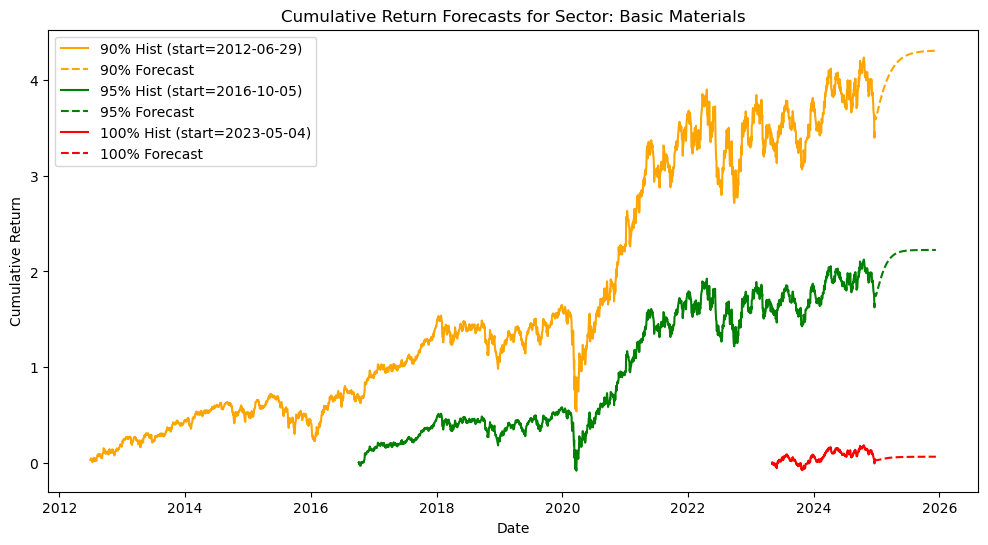

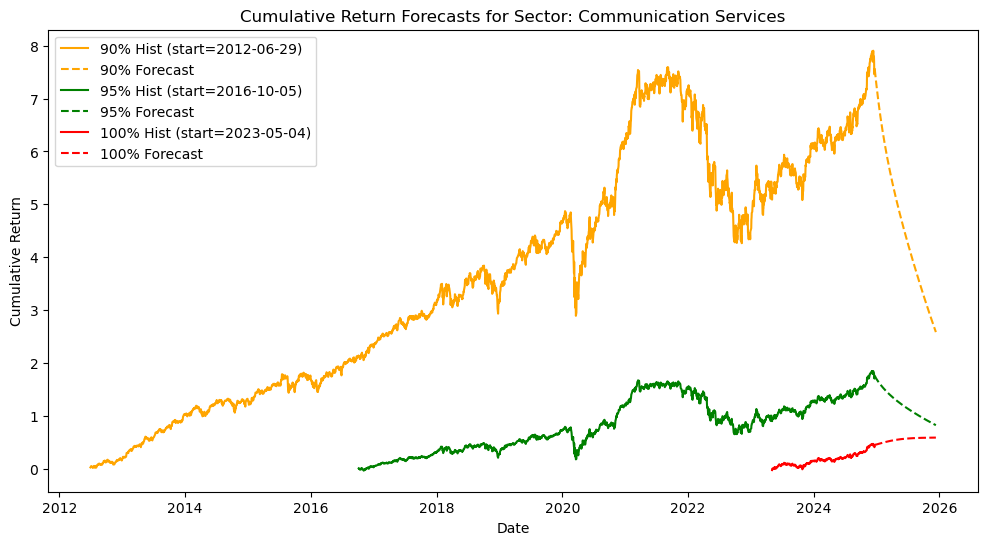

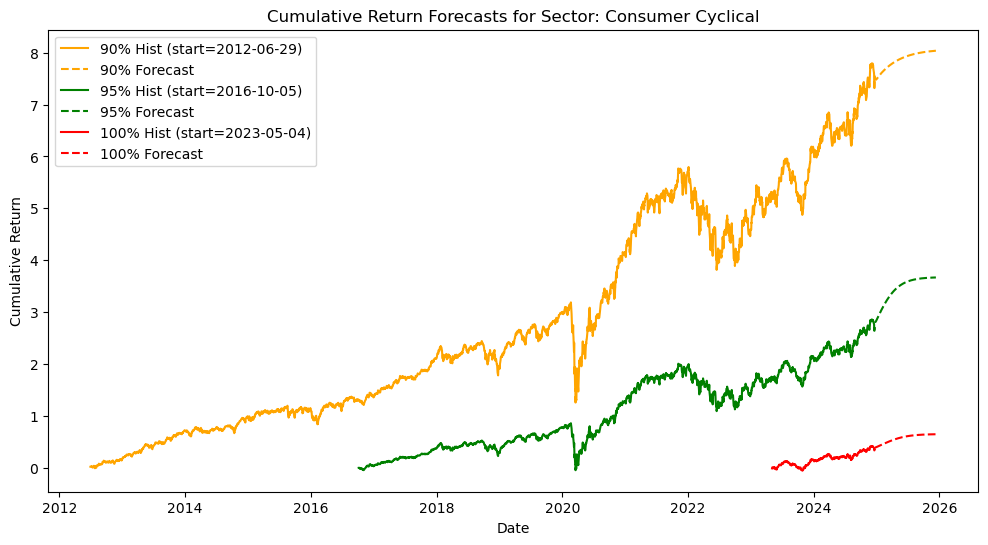

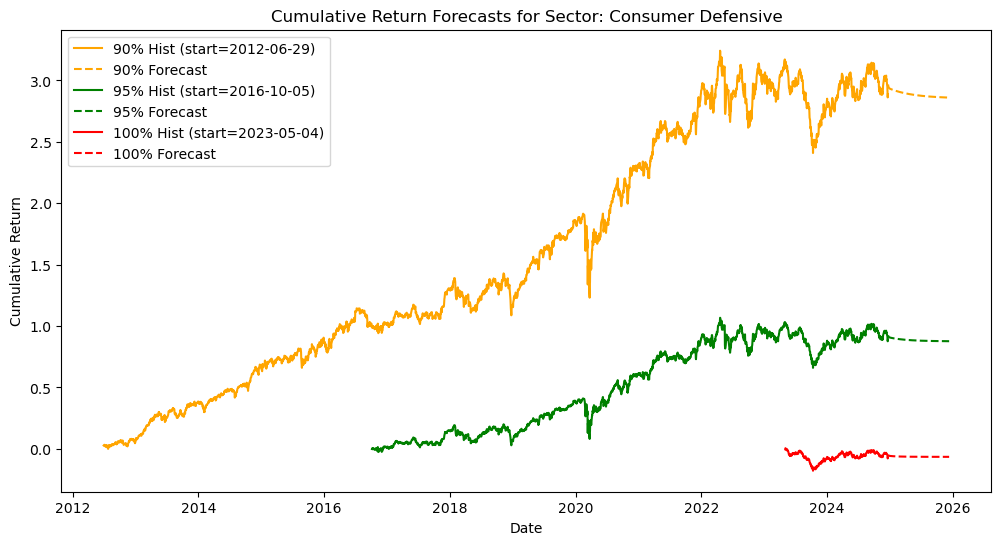

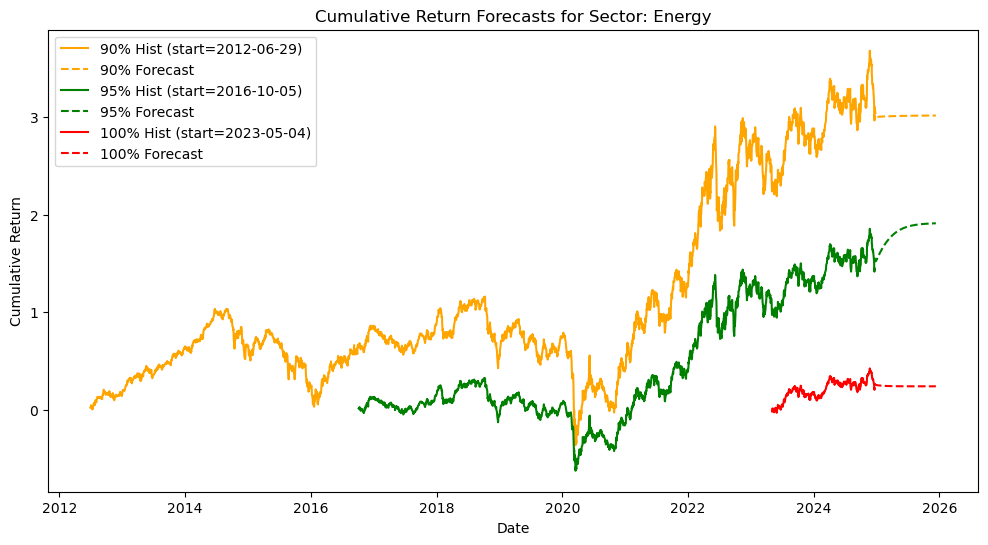

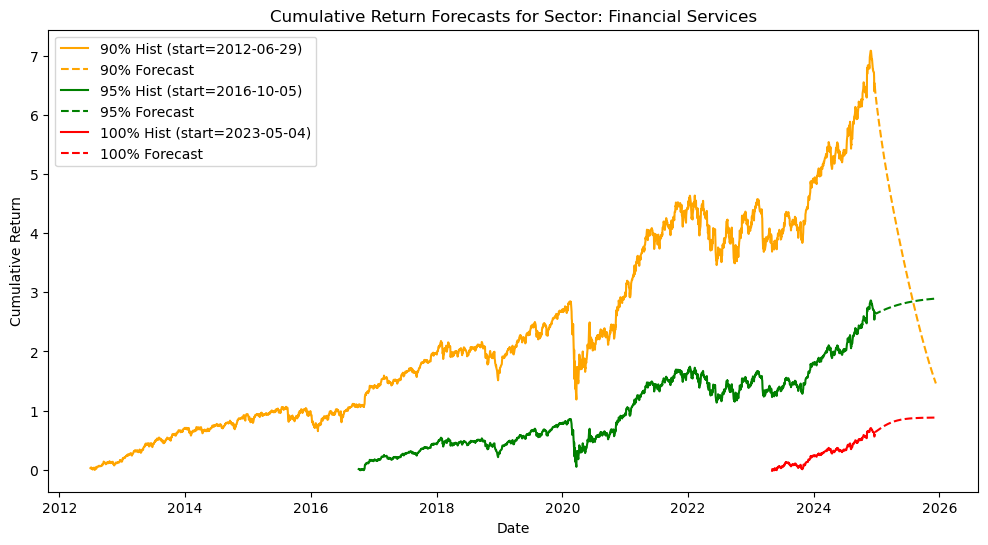

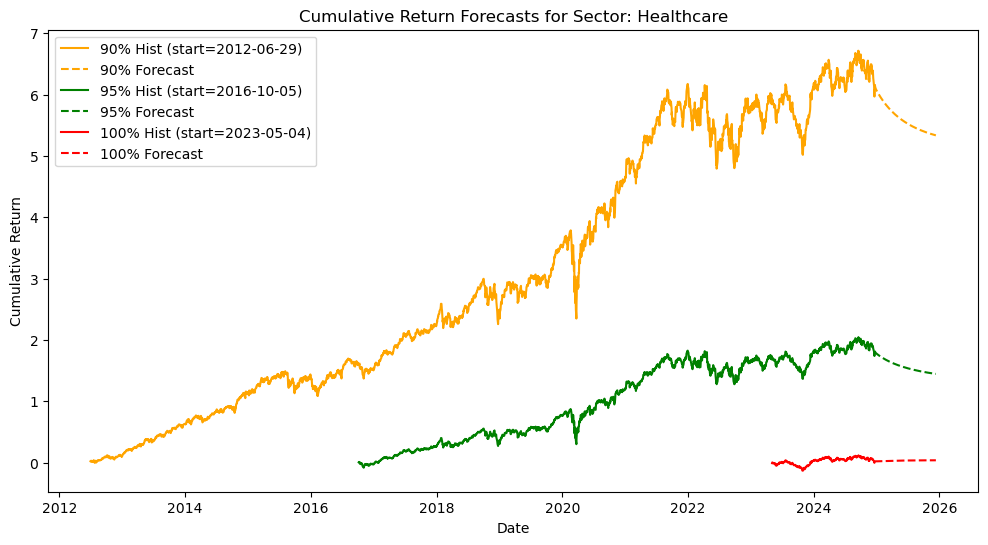

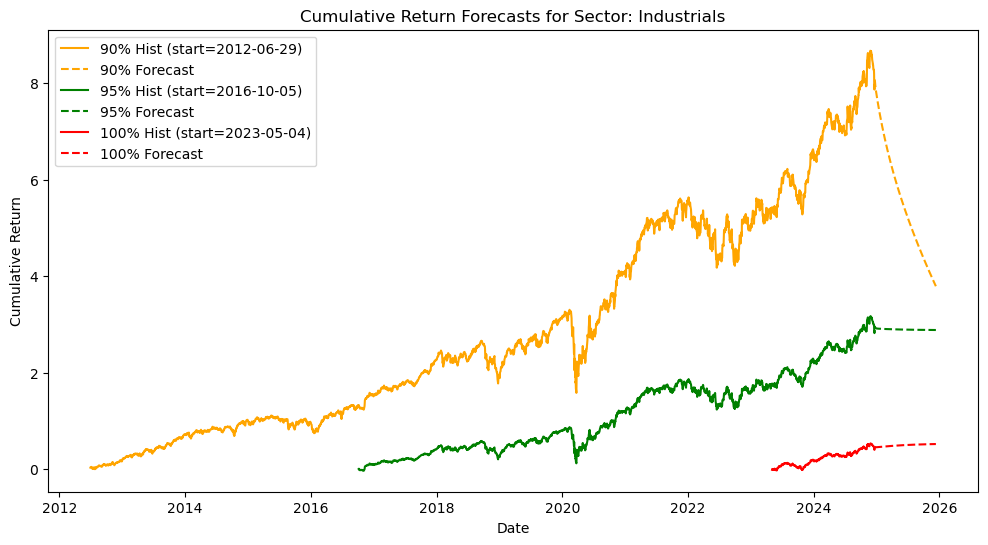

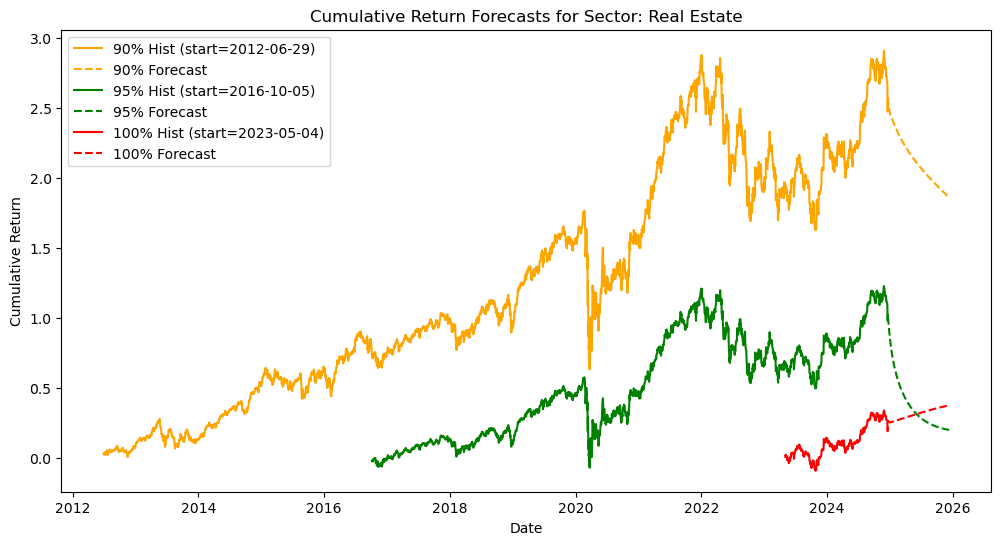

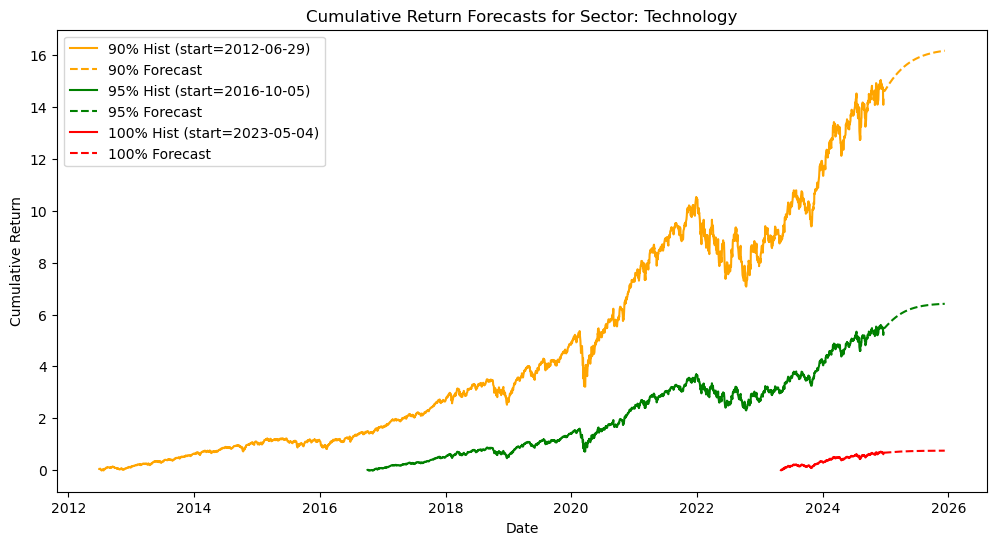

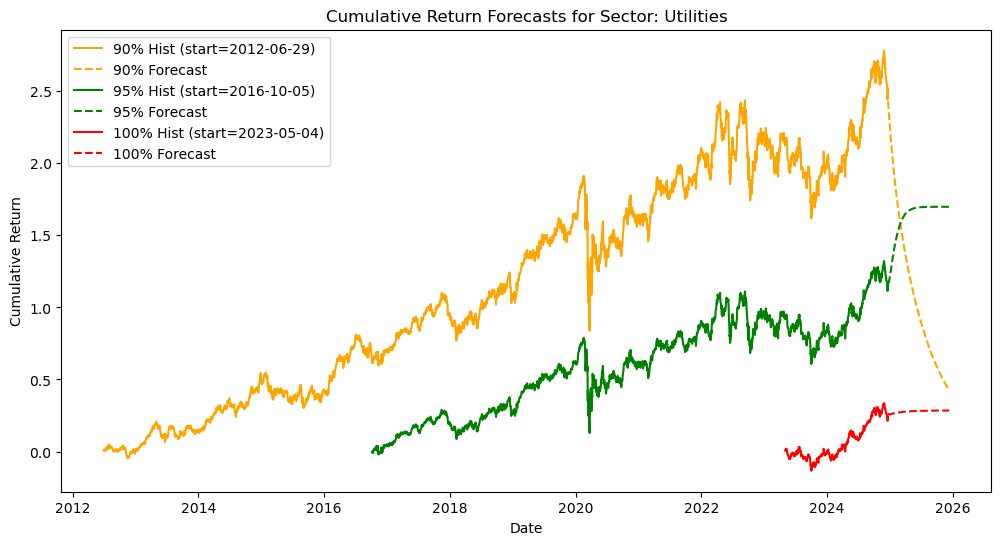

In [1428]:
# 4) Plot each sector on the same graph for all coverage levels

all_possible_sectors = set()
for cov_label, sector_dict in coverage_results.items():
    all_possible_sectors.update(sector_dict.keys())

colors = {'90%': 'orange', '95%': 'green', '100%': 'red'}

for sector in sorted(all_possible_sectors):
    plt.figure(figsize=(12, 6))
    plt.title(f"Cumulative Return Forecasts for Sector: {sector}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    
    # Plot each coverage's partial historical & forecast
    for cov_label in coverage_thresholds.keys():
        # If this sector doesn't exist for that coverage, skip
        if sector not in coverage_results[cov_label]:
            continue
        
        df_sec = coverage_results[cov_label][sector]['df_sector']
        df_forecast = coverage_results[cov_label][sector]['df_forecast']
        
        # Plot partial historical
        plt.plot(
            df_sec['Date'], 
            df_sec['Cumulative_return'], 
            label=f"{cov_label} Hist (start={df_sec['Date'].min().date()})",
            color=colors[cov_label], linestyle='-'
        )
        
        # Plot forecast
        plt.plot(
            df_forecast['Date'], 
            df_forecast['Cumulative_return_Forecast'],
            label=f"{cov_label} Forecast",
            color=colors[cov_label], linestyle='--'
        )
    
    plt.legend()
    plt.show()


In [1429]:
results_list = []

for cov_label, sector_dict in coverage_results.items():
    for sector, data_dict in sector_dict.items():
        df_forecast = data_dict['df_forecast']
        
        if len(df_forecast) > 0:
            # The first forecast value: day 1
            initial_val = df_forecast['Cumulative_return_Forecast'].iloc[0]
            # The final forecast value: day 356
            final_val = df_forecast['Cumulative_return_Forecast'].iloc[-1]
            total_increase = final_val - initial_val
        else:
            # Edge case: no forecast available
            total_increase = np.nan
        
        results_list.append([sector, cov_label, total_increase])

df_results = pd.DataFrame(results_list, columns=['Sector', 'Coverage', 'Forecasted_Increase'])

# Pivot or just display
df_results_pivot = df_results.pivot(index='Sector', columns='Coverage', values='Forecasted_Increase')

print("\n=== Yearly Total Forecasted Increase by Sector & Coverage ===")
print(df_results_pivot)



=== Yearly Total Forecasted Increase by Sector & Coverage ===
Coverage                    100%       90%       95%
Sector                                              
Basic Materials         0.017675  0.668992  0.449616
Communication Services  0.131434 -4.967217 -0.939691
Consumer Cyclical       0.247724  0.480055  0.844933
Consumer Defensive     -0.016592 -0.106707 -0.047638
Energy                 -0.031328 -0.093539  0.353197
Financial Services      0.231982 -5.031353  0.219270
Healthcare              0.008846 -0.834560 -0.375337
Industrials             0.050362 -4.283737 -0.083041
Real Estate             0.103329 -0.717837 -0.806357
Technology              0.071060  1.489273  0.921669
Utilities               0.018545 -2.003159  0.524365


### Forecast 2 - Marketcap

In [1431]:
def compute_sector_total_marketcap(df):
    """
    Groups by (Sector, Date) to sum the 'MarketCap' for each sector on each date.
    Returns a DataFrame with columns: [Sector, Date, MarketCap].
    """
    df_sector = (
        df.groupby(['Sector', 'Date'], as_index=False)['BackpropMarketCap']
          .sum()
          .rename(columns={'BackpropMarketCap': 'Total_MarketCap'})
    )
    df_sector.sort_values(by=['Sector', 'Date'], inplace=True)
    df_sector.reset_index(drop=True, inplace=True)
    return df_sector


In [1432]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def train_and_forecast_marketcap(df_sec, future_days=356, window_size=60):
    """
    Trains an LSTM model on the daily total market cap (df_sec['Total_MarketCap'])
    for the given sector. Forecasts the next `future_days` steps (iterative approach).

    Returns a DataFrame with [Date, MarketCap_Forecast].
    """
    # 1) Sort by Date
    df_sec = df_sec.sort_values(by='Date').reset_index(drop=True)

    # 2) Extract the series: 'Total_MarketCap'
    data = df_sec[['Total_MarketCap']].values  # shape: (num_samples, 1)

    # 3) Scale the data to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # 4) Create sequences with window_size timesteps
    x_data, y_data = [], []
    for i in range(window_size, len(scaled_data)):
        x_data.append(scaled_data[i - window_size:i, 0])  # previous 60
        y_data.append(scaled_data[i, 0])                  # the next point
    x_data = np.array(x_data)
    y_data = np.array(y_data)

    # Reshape x_data => (samples, timesteps, features=1)
    x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

    # 5) Build LSTM model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_data, y_data, batch_size=32, epochs=10, verbose=0)

    # 6) Rolling forecast
    if len(scaled_data) < window_size:
        return pd.DataFrame(columns=['Date', 'MarketCap_Forecast'])

    last_window = scaled_data[-window_size:].copy()
    current_batch = last_window.reshape((1, window_size, 1))

    future_forecasts_scaled = []
    for _ in range(future_days):
        next_pred_scaled = model.predict(current_batch)[0][0]
        future_forecasts_scaled.append(next_pred_scaled)

        # Shift window by 1 => drop oldest, add new
        current_batch = np.append(
            current_batch[:, 1:, :],
            [[[next_pred_scaled]]],
            axis=1
        )

    # 7) Invert scaling
    future_forecasts_scaled = np.array(future_forecasts_scaled).reshape(-1, 1)
    future_forecasts = scaler.inverse_transform(future_forecasts_scaled).ravel()

    # 8) Build forecast DataFrame
    last_date = df_sec['Date'].iloc[-1]
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=future_days,
        freq='D'
    )
    df_forecast = pd.DataFrame({
        'Date': future_dates,
        'MarketCap_Forecast': future_forecasts
    })
    return df_forecast


In [ ]:
coverage_results_marketcap = {}

for coverage_label, cov_date in coverage_thresholds.items():
    print(f"\n=== Processing coverage {coverage_label}, date >= {cov_date.date()} ===")
    
    # 1) Filter to coverage date & drop symbols with nulls in Pct_change_AdjClose
    df_sub = get_coverage_subset(df_stocks_forecast, cov_date)

    # 2) Compute total marketcap by sector
    df_sector_cap = compute_sector_total_marketcap(df_sub)

    # 3) Train & forecast for each sector
    sector_dict = {}
    for sector in df_sector_cap['Sector'].unique():
        df_sec = df_sector_cap[df_sector_cap['Sector'] == sector].copy()
        
        df_forecast = train_and_forecast_marketcap(df_sec, future_days=356, window_size=60)
        
        sector_dict[sector] = {
            'df_sector': df_sec,
            'df_forecast': df_forecast
        }
    
    coverage_results_marketcap[coverage_label] = sector_dict

print("Done with MarketCap-based forecasts.")


=== Processing coverage 90%, date >= 2012-06-29 ===


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

In [ ]:
import matplotlib.pyplot as plt

for coverage_label, sector_dict in coverage_results_marketcap.items():
    for sector, data_dict in sector_dict.items():
        df_sec = data_dict['df_sector']
        df_forecast = data_dict['df_forecast']

        plt.figure(figsize=(12,6))
        plt.plot(df_sec['Date'], df_sec['Total_MarketCap'],
                 label='Historical MarketCap', color='blue')

        plt.plot(df_forecast['Date'], df_forecast['MarketCap_Forecast'],
                 label='Forecast MarketCap (356 days)', color='orange')

        plt.title(f"{sector} - MarketCap Forecast ({coverage_label})")
        plt.xlabel("Date")
        plt.ylabel("Total MarketCap ($)")
        plt.legend()
        plt.show()

In [ ]:
print("done all")

# IGNORE BELOW

### Forecast 3

In [440]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------------------------------------------------------
# 1) Check for nulls, ensure 'Date' is datetime
# -------------------------------------------------------------------------
print("Null values per column:\n", df_stocks_forecast.isnull().sum())
df_stocks_forecast['Date'] = pd.to_datetime(df_stocks_forecast['Date'])

# -------------------------------------------------------------------------
# 2) Sort by Symbol & Date so we can calculate % changes properly
# -------------------------------------------------------------------------
df_stocks_forecast.sort_values(by=['Symbol', 'Date'], inplace=True)
df_stocks_forecast.reset_index(drop=True, inplace=True)

# -------------------------------------------------------------------------
# 3) Calculate daily % change for each Symbol (Adj Close)
# -------------------------------------------------------------------------
df_stocks_forecast['Pct_change_AdjClose'] = df_stocks_forecast.groupby('Symbol')['Adj Close'].pct_change()

df_stocks_forecast.describe()

# Handle NaNs on the first day per symbol (e.g., fill with 0)
df_stocks_forecast['Pct_change_AdjClose'] = df_stocks_forecast['Pct_change_AdjClose']

df_stocks_forecast.head()

Null values per column:
 Date              0
Symbol            0
Adj Close    100475
Sector            0
dtype: int64


/var/folders/db/g3_b7s9n3fvdsyb4pfxmnj200000gn/T/ipykernel_66889/3207147400.py:23: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_stocks_forecast['Pct_change_AdjClose'] = df_stocks_forecast.groupby('Symbol')['Adj Close'].pct_change()


,Date,Symbol,Adj Close,Sector,Pct_change_AdjClose
0,2010-01-04,A,20.053030,Healthcare,NaN
1,2010-01-05,A,19.835201,Healthcare,-0.010863
2,2010-01-06,A,19.764729,Healthcare,-0.003553
3,2010-01-07,A,19.739098,Healthcare,-0.001297
4,2010-01-08,A,19.732698,Healthcare,-0.000324


Null values per column:
 Date                   0
Symbol                 0
Adj Close              0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
Pct_change_AdjClose    0
Pct_change_Volume      0
Sector_x               0
Sector_y               0
Sector                 0
dtype: int64
Sectors found: ['Basic Materials' 'Communication Services' 'Consumer Cyclical'
 'Consumer Defensive' 'Energy' 'Financial Services' 'Healthcare'
 'Industrials' 'Real Estate' 'Technology' 'Utilities']

Processing sector: Basic Materials


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

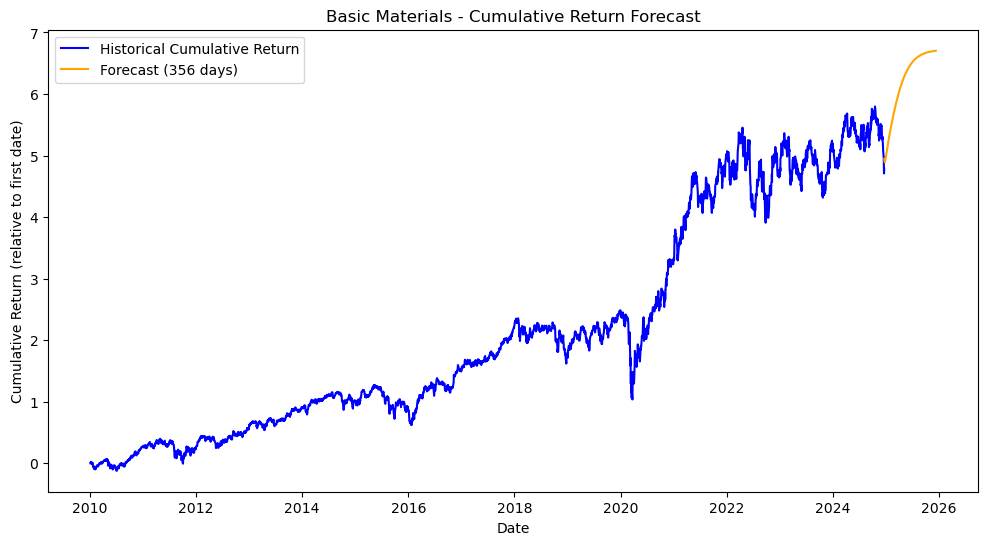


Processing sector: Communication Services


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

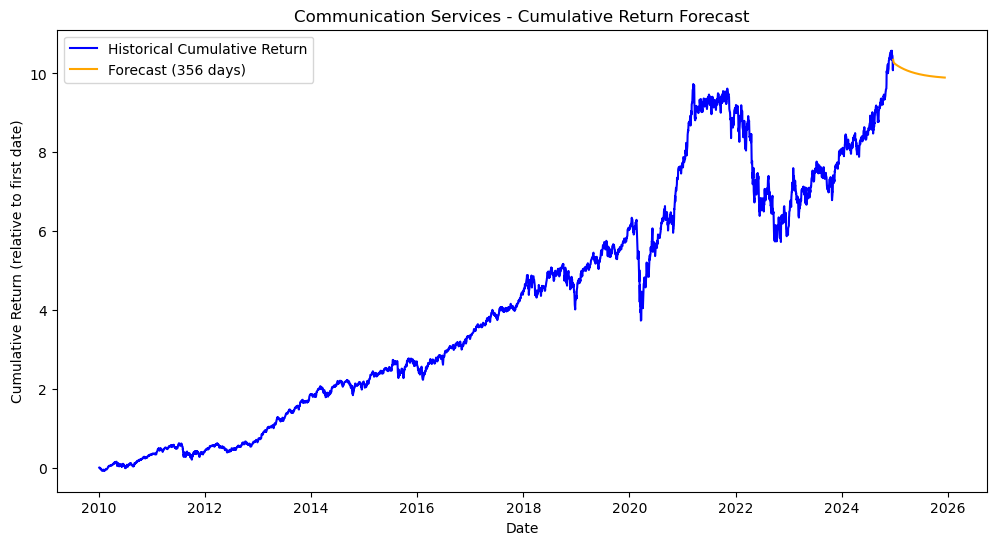


Processing sector: Consumer Cyclical


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━

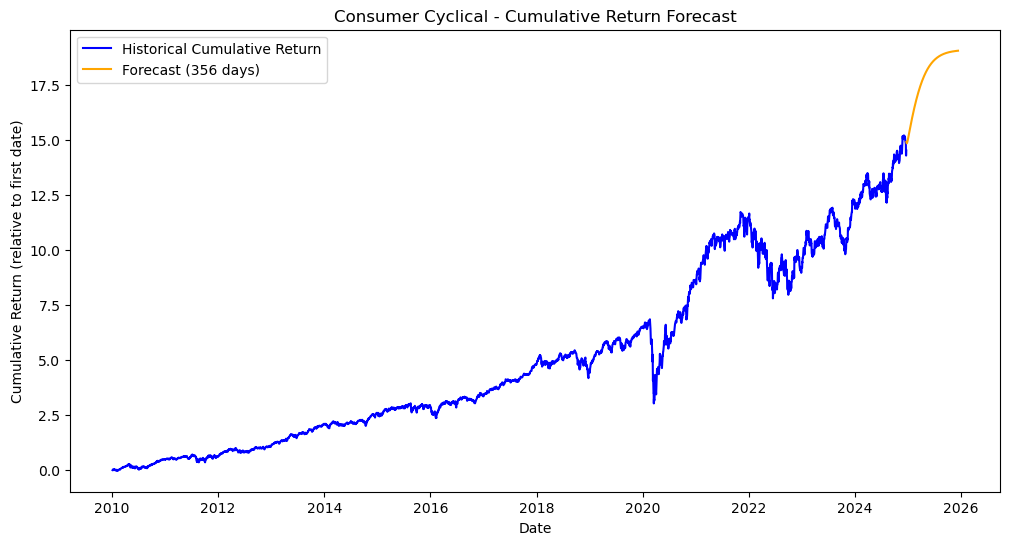


Processing sector: Consumer Defensive


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

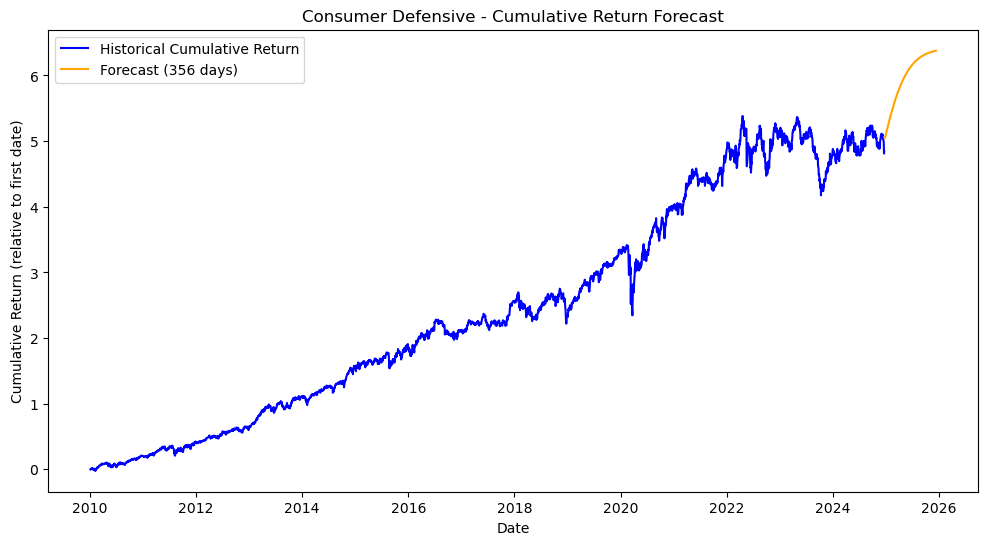


Processing sector: Energy


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

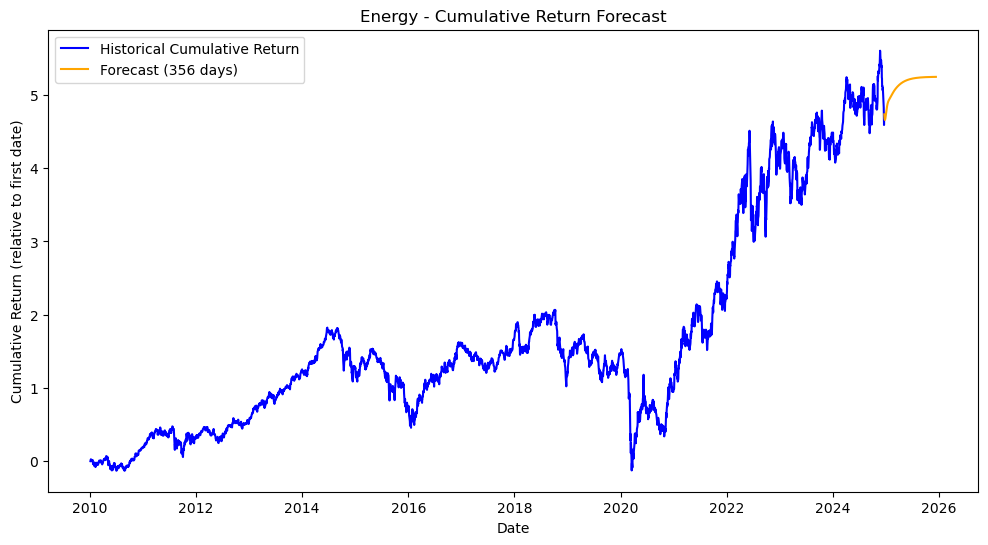


Processing sector: Financial Services


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

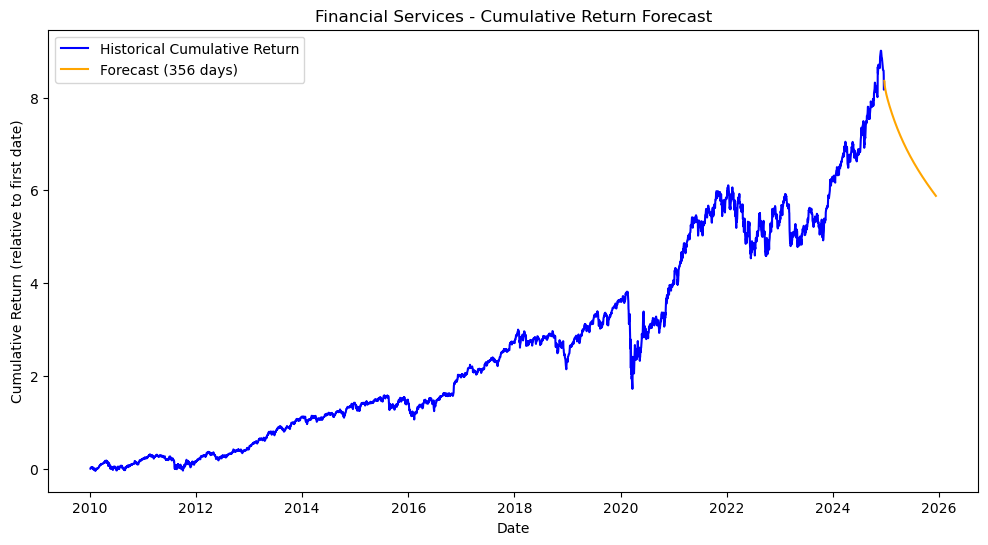


Processing sector: Healthcare


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

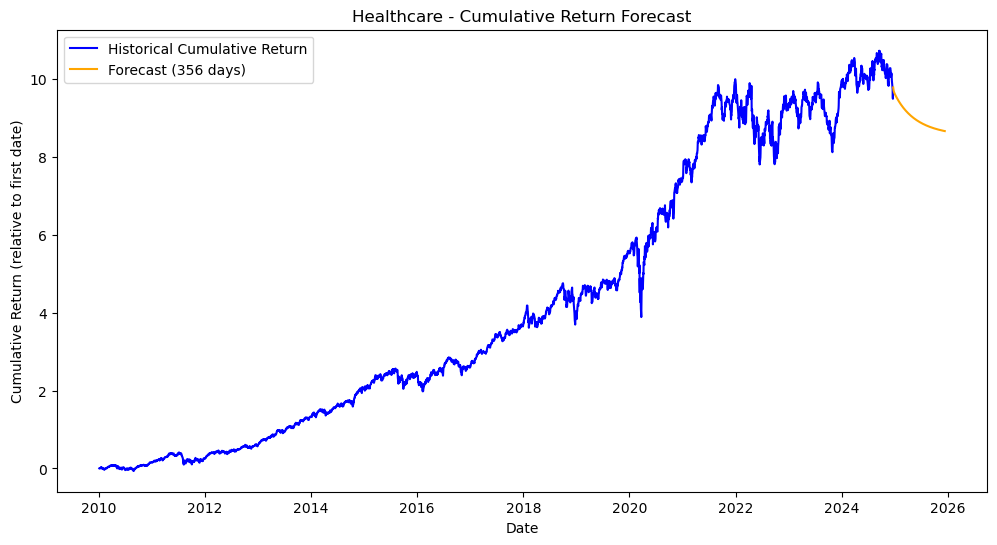


Processing sector: Industrials


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

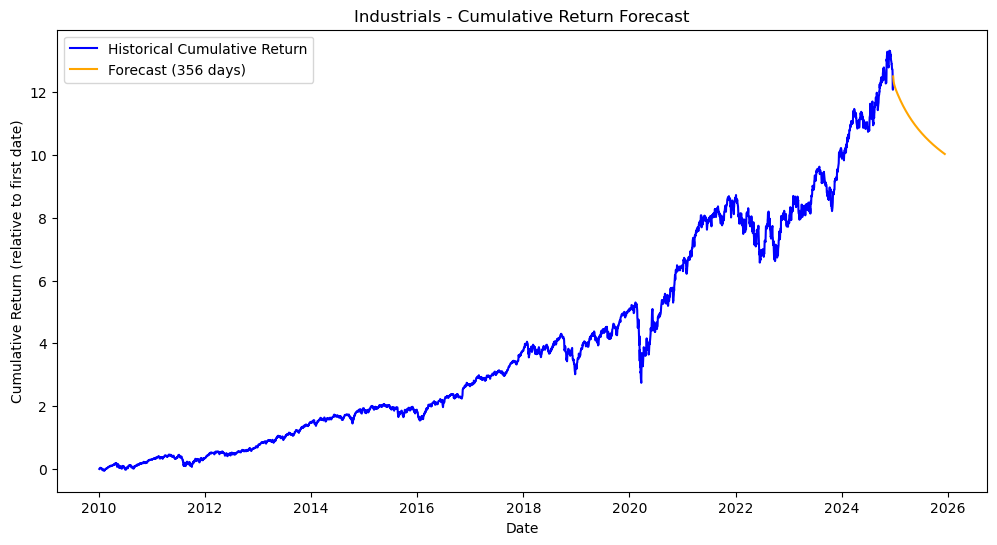


Processing sector: Real Estate


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

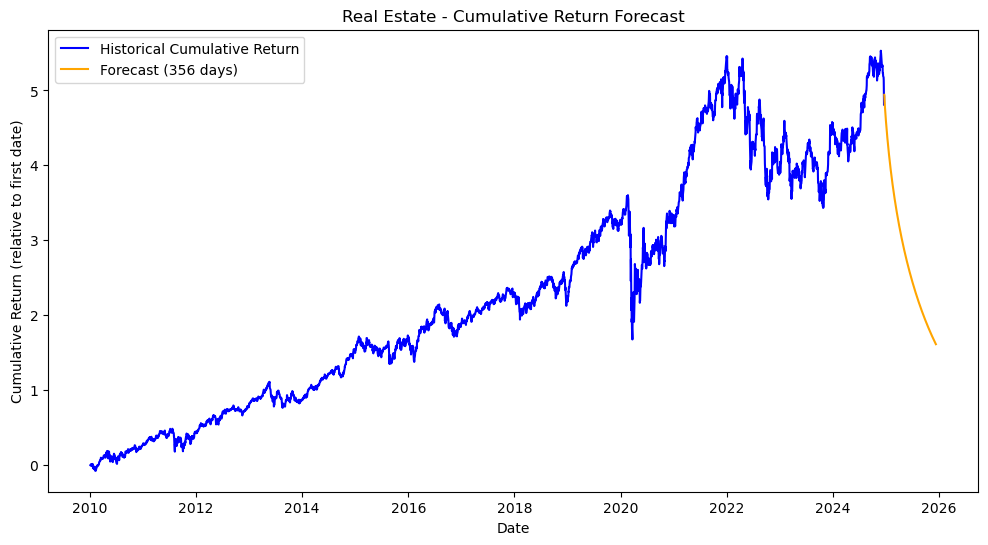


Processing sector: Technology


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

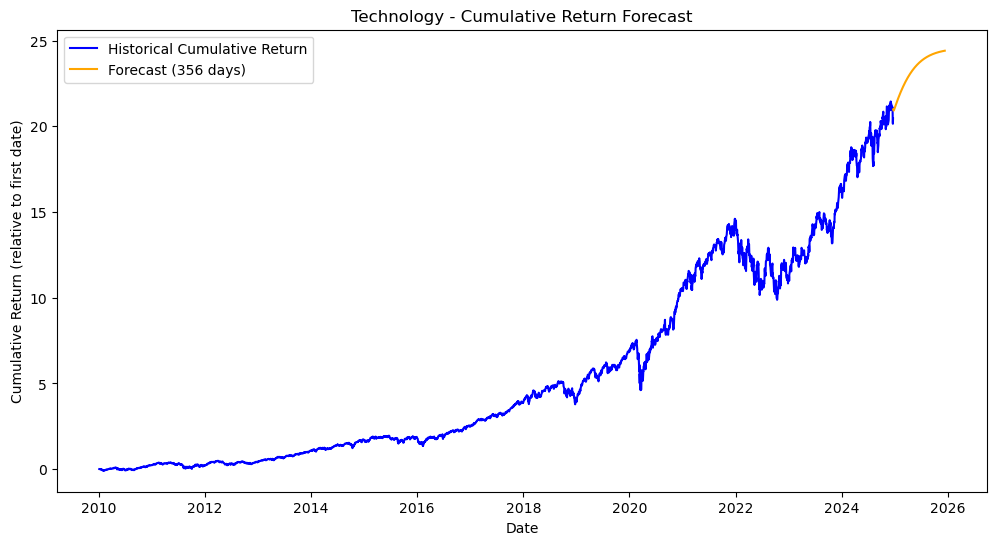


Processing sector: Utilities


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

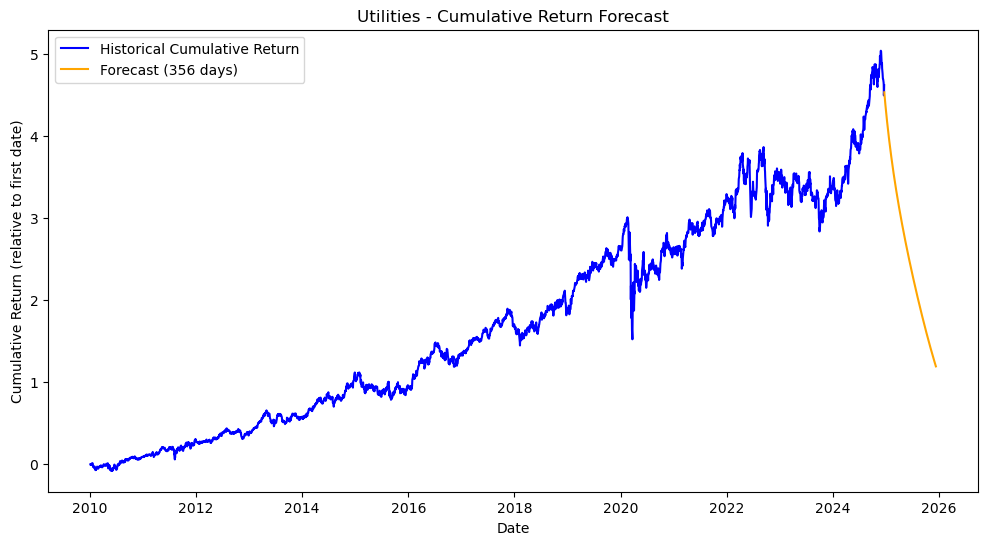


Combined Forecasts for All Sectors:
         Date  Cumulative_return_Forecast           Sector
0 2024-12-21                    4.945772  Basic Materials
1 2024-12-22                    4.912921  Basic Materials
2 2024-12-23                    4.897492  Basic Materials
3 2024-12-24                    4.892810  Basic Materials
4 2024-12-25                    4.894937  Basic Materials


In [214]:

# -------------------------------------------------------------------------
# 4) Group by Sector & Date to get average daily % change
# -------------------------------------------------------------------------
# We'll assume df_stocks contains a 'Sector' column.
df_sector = (
    df_stocks_forecast
    .groupby(['Sector', 'Date'], as_index=False)
    .agg({
        'Pct_change_AdjClose': 'mean'
    })
)
# Now df_sector has: [Sector, Date, Pct_change_AdjClose]

# -------------------------------------------------------------------------
# 5) Compute cumulative day-on-day percentage change from the start
# -------------------------------------------------------------------------
# Sort by Sector, Date again to ensure chronological order
df_stocks_forecast.sort_values(by=['Sector', 'Date'], inplace=True)
df_stocks_forecast.reset_index(drop=True, inplace=True)

# For each sector, we do a running product of (1 + daily_return),
# then subtract 1 to get the total percentage change vs. the earliest date.
df_stocks_forecast['Cumulative_return'] = (
    1 + df_stocks_forecast['Pct_change_AdjClose']
).groupby(df_stocks_forecast['Sector']).cumprod() - 1

# So now df_sector for each sector has a time series of Cumulative_return,
# e.g., 0.05 means +5% from that sector's start date.

# -------------------------------------------------------------------------
# 6) Function to train multi-layer LSTM & forecast on the sector’s cumulative series
# -------------------------------------------------------------------------
def train_and_forecast_cumulative(df_sec, future_days=356, window_size=60):
    """
    Trains an LSTM model on the entire time series of 'Cumulative_return' 
    for the given sector. Forecasts the next `future_days` steps 
    (iterative approach).
    
    Returns a DataFrame: [Date, Cumulative_return_Forecast].
    """
    # 1) Sort by Date (important for time series)
    df_sec = df_sec.sort_values(by='Date').reset_index(drop=True)
    
    # 2) Extract the single feature: 'Cumulative_return'
    data = df_sec[['Cumulative_return']].values  # shape -> (num_samples, 1)

    # 3) Scale the data to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)  # shape -> (num_samples, 1)

    # 4) Create sequences with window_size timesteps
    x_data, y_data = [], []
    for i in range(window_size, len(scaled_data)):
        x_data.append(scaled_data[i - window_size:i, 0])  # the previous 60
        y_data.append(scaled_data[i, 0])                  # the next point

    x_data = np.array(x_data)   # shape -> (samples, window_size)
    y_data = np.array(y_data)   # shape -> (samples,)

    # Reshape x_data into (samples, timesteps, features=1)
    x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

    # 5) Build a multi-layer LSTM model
    model = Sequential()
    # First LSTM layer (return_sequences=True to feed into second LSTM)
    model.add(LSTM(50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
    # Second LSTM layer
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))  # single output: next day's cumulative return

    model.compile(optimizer='adam', loss='mean_squared_error')

    # 6) Train on ALL data from df_sec
    model.fit(x_data, y_data, batch_size=32, epochs=10, verbose=0)

    # ----------------------------------------------------------------------
    # 7) Forecast the next `future_days` points (iterative rolling approach)
    # ----------------------------------------------------------------------
    # Start from the last `window_size` points of scaled_data
    last_window = scaled_data[-window_size:].copy()  # shape -> (60, 1)
    current_batch = last_window.reshape((1, window_size, 1))  # shape -> (1,60,1)

    future_forecasts_scaled = []
    for _ in range(future_days):
        # 1) Predict next scaled cumulative return
        next_pred_scaled = model.predict(current_batch)[0][0]  # shape -> scalar

        # 2) Append to list
        future_forecasts_scaled.append(next_pred_scaled)

        # 3) Shift window by 1
        #    Drop the oldest value and add this new one
        current_batch = np.append(
            current_batch[:, 1:, :],  # shape -> (1, window_size-1, 1)
            [[[next_pred_scaled]]],  # shape -> (1,1,1)
            axis=1
        )  # Now shape -> (1, window_size, 1)

    # Convert to array and invert the scaling
    future_forecasts_scaled = np.array(future_forecasts_scaled).reshape(-1, 1)
    future_forecasts = scaler.inverse_transform(future_forecasts_scaled).ravel()

    # 8) Build forecast DataFrame
    last_date = df_sec['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                 periods=future_days,
                                 freq='D')
    
    df_forecast = pd.DataFrame({
        'Date': future_dates,
        'Cumulative_return_Forecast': future_forecasts
    })

    return df_forecast

# -------------------------------------------------------------------------
# 7) Loop over each sector, train & forecast the CUMULATIVE return
# -------------------------------------------------------------------------
all_sectors = df_sector['Sector'].unique()
print("Sectors found:", all_sectors)

sector_forecasts = {}

for sector in all_sectors:
    print(f"\nProcessing sector: {sector}")
    # Subset data for this sector
    df_sec = df_sector[df_sector['Sector'] == sector].copy()
    
    # Train & forecast
    df_forecast = train_and_forecast_cumulative(
        df_sec,
        future_days=356,
        window_size=60
    )
    
    sector_forecasts[sector] = df_forecast

    # ---------------------------------------------------
    # Plot historical vs. forecast
    # ---------------------------------------------------
    plt.figure(figsize=(12, 6))
    # Plot historical cumulative return
    plt.plot(df_sec['Date'], df_sec['Cumulative_return'], label='Historical Cumulative Return', color='blue')
    # Plot forecast
    plt.plot(df_forecast['Date'], df_forecast['Cumulative_return_Forecast'], label='Forecast (356 days)', color='orange')
    plt.title(f"{sector} - Cumulative Return Forecast")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (relative to first date)")
    plt.legend()
    plt.show()

# Copied

Null values per column:
 Date                   0
Symbol                 0
Adj Close              0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
Pct_change_AdjClose    0
Pct_change_Volume      0
Sector_x               0
Sector_y               0
Sector                 0
dtype: int64
Sectors found: ['Basic Materials' 'Communication Services' 'Consumer Cyclical'
 'Consumer Defensive' 'Energy' 'Financial Services' 'Healthcare'
 'Industrials' 'Real Estate' 'Technology' 'Utilities']

Processing sector: Basic Materials


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

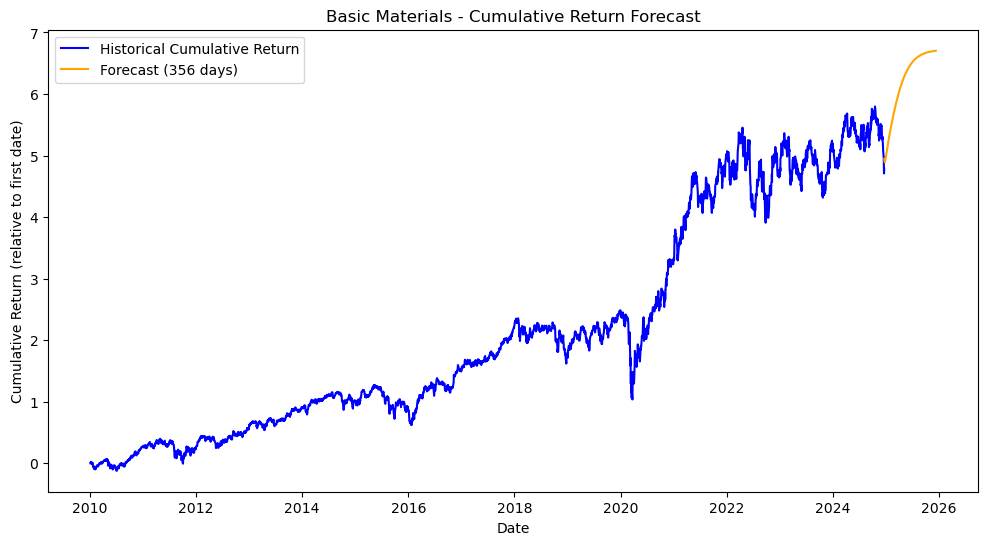


Processing sector: Communication Services


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

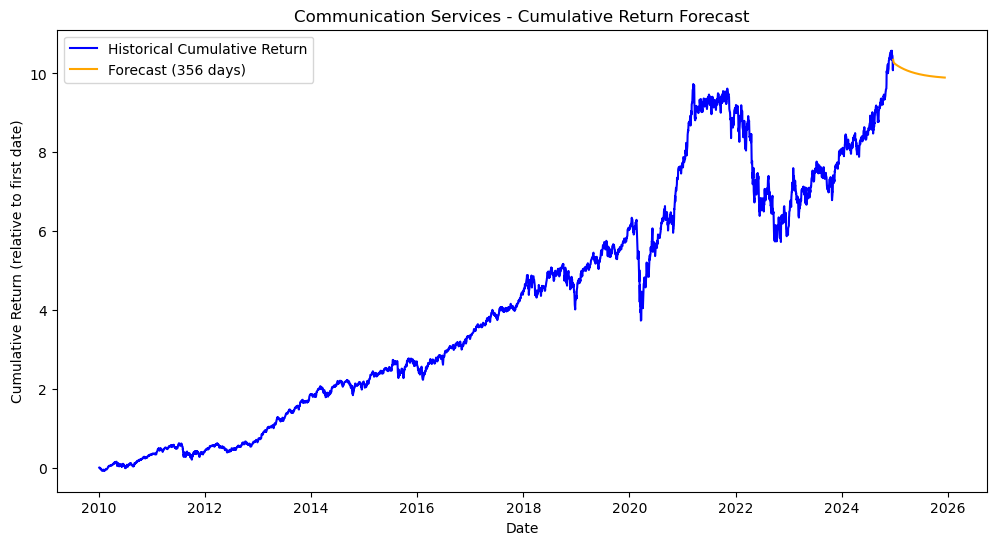


Processing sector: Consumer Cyclical


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━

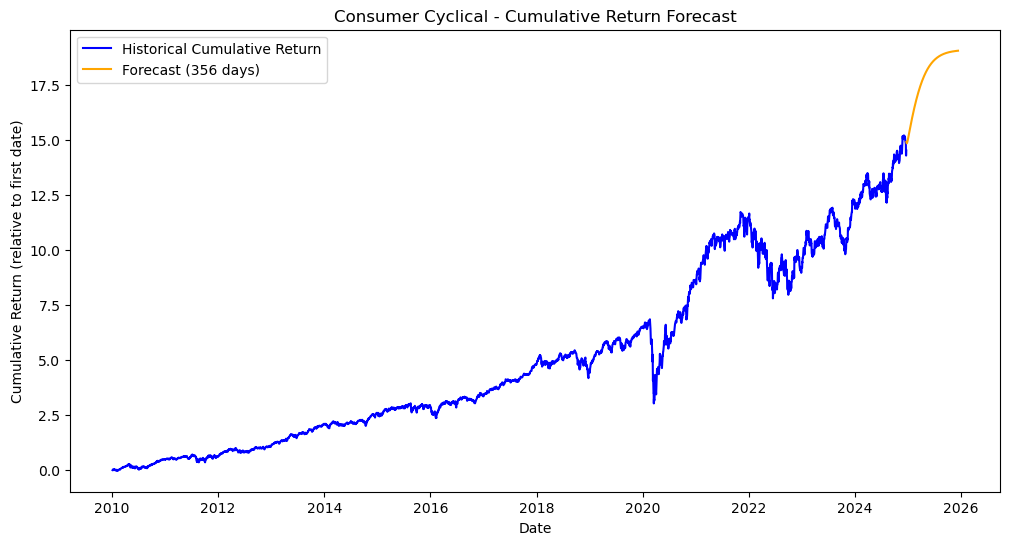


Processing sector: Consumer Defensive


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

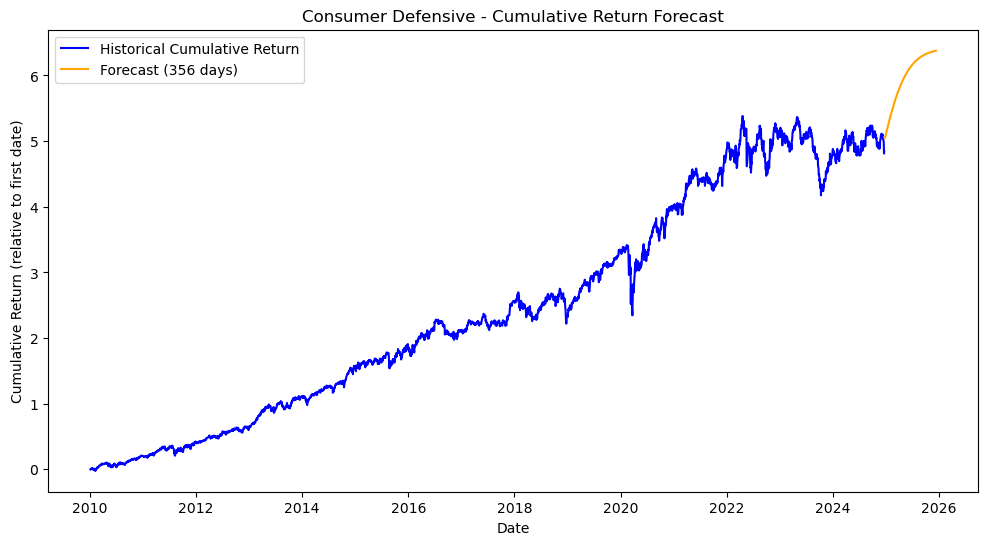


Processing sector: Energy


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

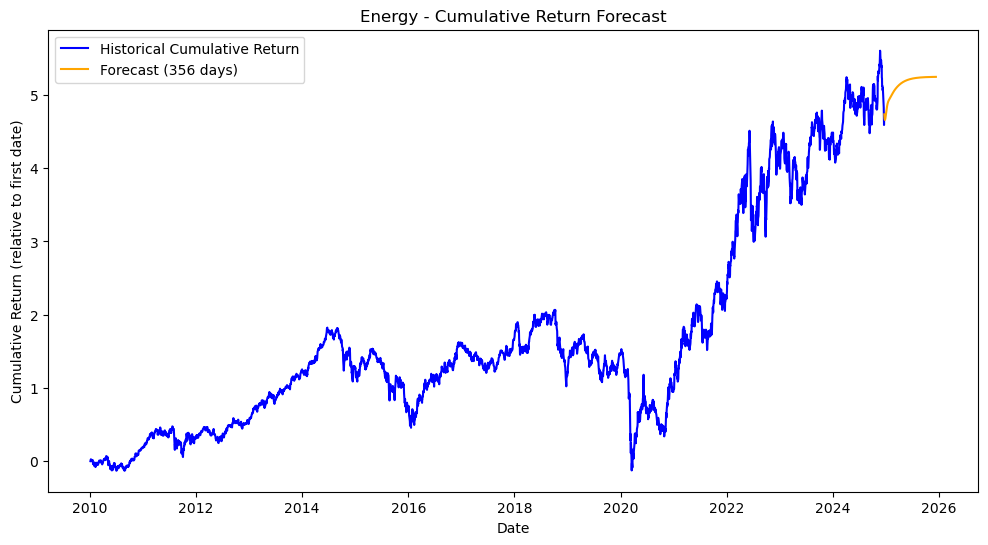


Processing sector: Financial Services


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

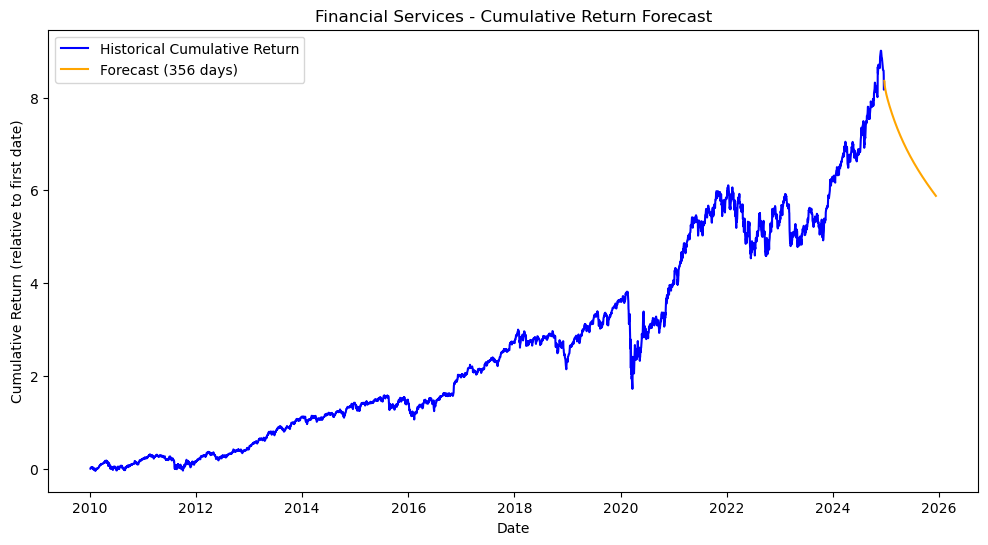


Processing sector: Healthcare


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

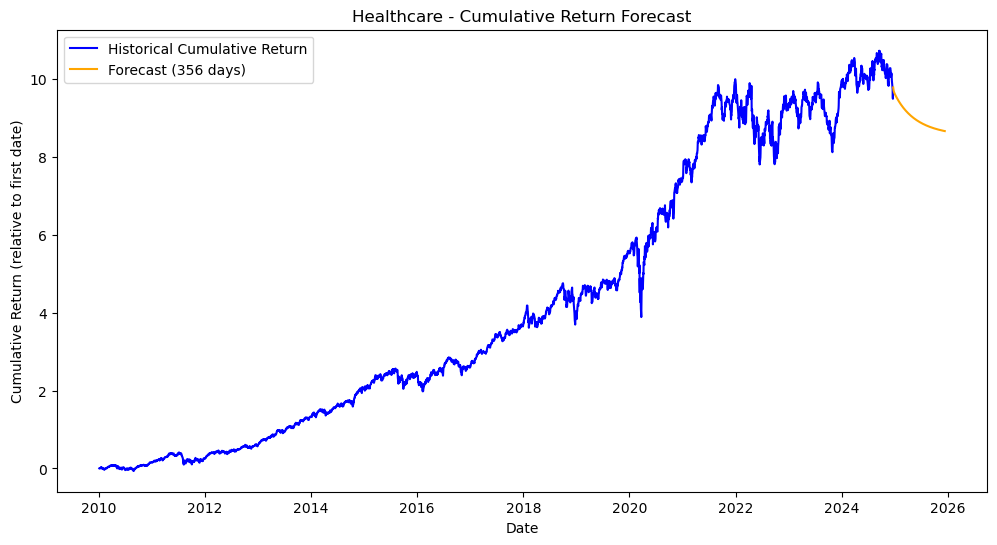


Processing sector: Industrials


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

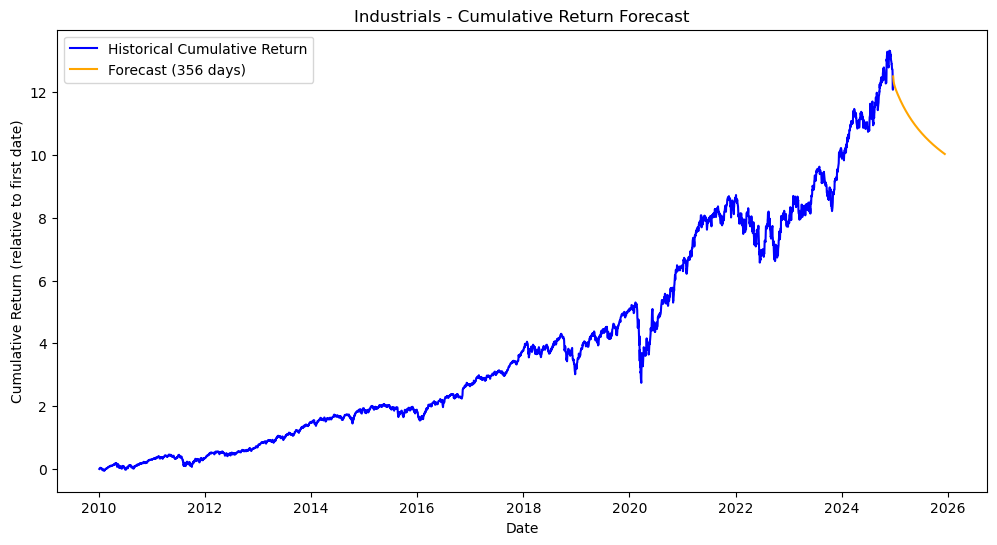


Processing sector: Real Estate


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

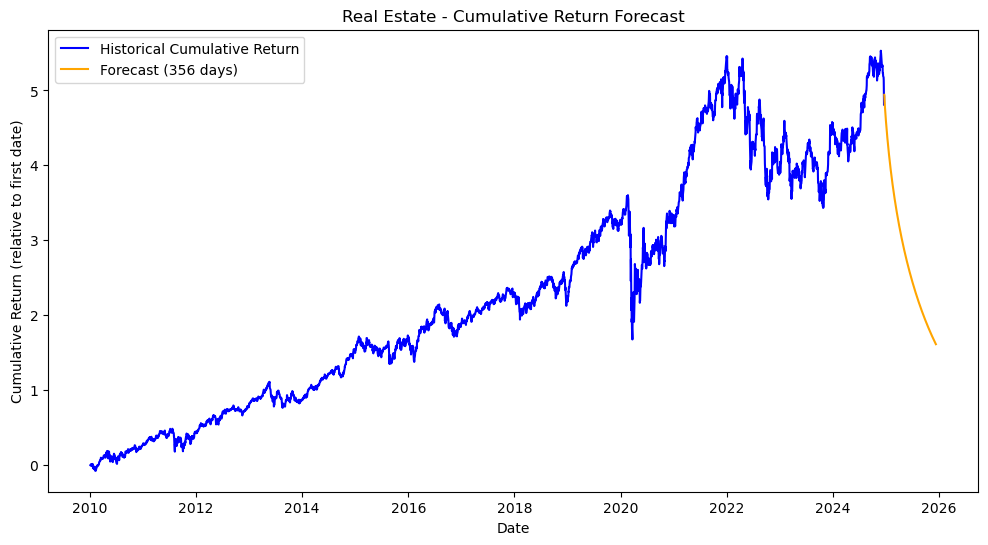


Processing sector: Technology


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━

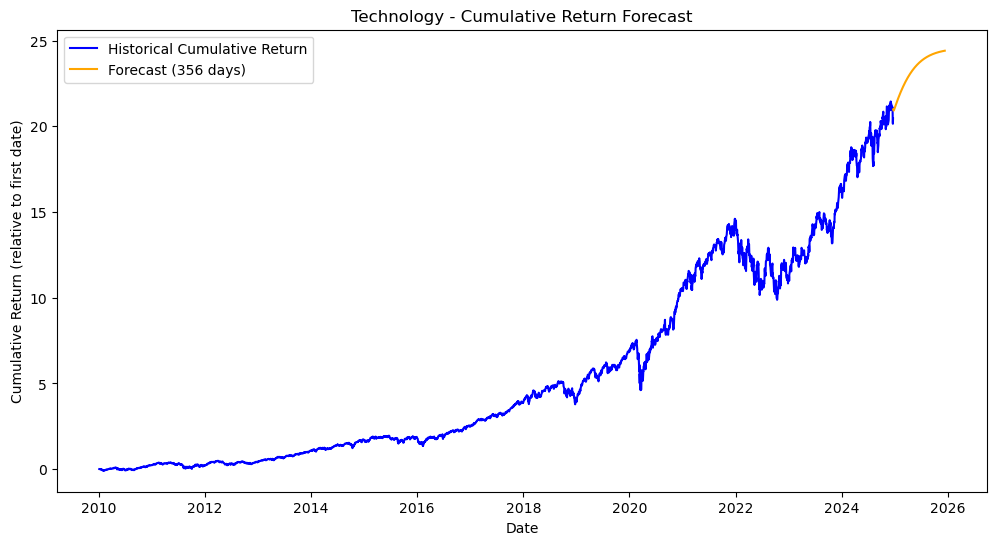


Processing sector: Utilities


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━

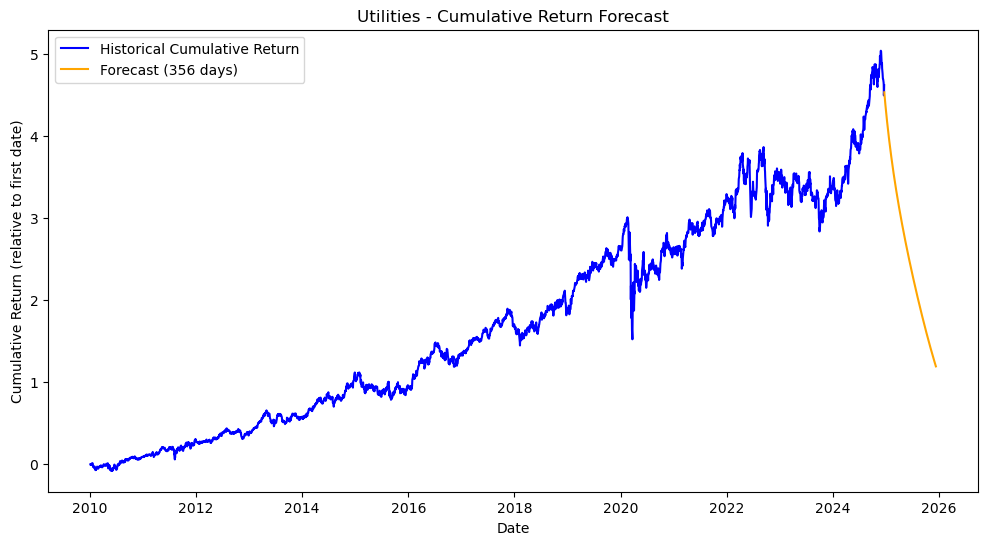


Combined Forecasts for All Sectors:
         Date  Cumulative_return_Forecast           Sector
0 2024-12-21                    4.945772  Basic Materials
1 2024-12-22                    4.912921  Basic Materials
2 2024-12-23                    4.897492  Basic Materials
3 2024-12-24                    4.892810  Basic Materials
4 2024-12-25                    4.894937  Basic Materials


In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------------------------------------------------------
# 1) Check for nulls, ensure 'Date' is datetime
# -------------------------------------------------------------------------
print("Null values per column:\n", df_stocks.isnull().sum())
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# -------------------------------------------------------------------------
# 2) Sort by Symbol & Date so we can calculate % changes properly
# -------------------------------------------------------------------------
df_stocks.sort_values(by=['Symbol', 'Date'], inplace=True)
df_stocks.reset_index(drop=True, inplace=True)

# -------------------------------------------------------------------------
# 3) Calculate daily % change for each Symbol (Adj Close)
# -------------------------------------------------------------------------
df_stocks['Pct_change_AdjClose'] = df_stocks.groupby('Symbol')['Adj Close'].pct_change()

# Handle NaNs on the first day per symbol (e.g., fill with 0)
df_stocks['Pct_change_AdjClose'] = df_stocks['Pct_change_AdjClose'].fillna(0)

# -------------------------------------------------------------------------
# 4) Group by Sector & Date to get average daily % change
# -------------------------------------------------------------------------
# We'll assume df_stocks contains a 'Sector' column.
df_sector = (
    df_stocks
    .groupby(['Sector', 'Date'], as_index=False)
    .agg({
        'Pct_change_AdjClose': 'mean'
    })
)
# Now df_sector has: [Sector, Date, Pct_change_AdjClose]

# -------------------------------------------------------------------------
# 5) Compute cumulative day-on-day percentage change from the start
# -------------------------------------------------------------------------
# Sort by Sector, Date again to ensure chronological order
df_sector.sort_values(by=['Sector', 'Date'], inplace=True)
df_sector.reset_index(drop=True, inplace=True)

# For each sector, we do a running product of (1 + daily_return),
# then subtract 1 to get the total percentage change vs. the earliest date.
df_sector['Cumulative_return'] = (
    1 + df_sector['Pct_change_AdjClose']
).groupby(df_sector['Sector']).cumprod() - 1

# So now df_sector for each sector has a time series of Cumulative_return,
# e.g., 0.05 means +5% from that sector's start date.

# -------------------------------------------------------------------------
# 6) Function to train multi-layer LSTM & forecast on the sector’s cumulative series
# -------------------------------------------------------------------------
def train_and_forecast_cumulative(df_sec, future_days=356, window_size=60):
    """
    Trains an LSTM model on the entire time series of 'Cumulative_return' 
    for the given sector. Forecasts the next `future_days` steps 
    (iterative approach).
    
    Returns a DataFrame: [Date, Cumulative_return_Forecast].
    """
    # 1) Sort by Date (important for time series)
    df_sec = df_sec.sort_values(by='Date').reset_index(drop=True)
    
    # 2) Extract the single feature: 'Cumulative_return'
    data = df_sec[['Cumulative_return']].values  # shape -> (num_samples, 1)

    # 3) Scale the data to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)  # shape -> (num_samples, 1)

    # 4) Create sequences with window_size timesteps
    x_data, y_data = [], []
    for i in range(window_size, len(scaled_data)):
        x_data.append(scaled_data[i - window_size:i, 0])  # the previous 60
        y_data.append(scaled_data[i, 0])                  # the next point

    x_data = np.array(x_data)   # shape -> (samples, window_size)
    y_data = np.array(y_data)   # shape -> (samples,)

    # Reshape x_data into (samples, timesteps, features=1)
    x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

    # 5) Build a multi-layer LSTM model
    model = Sequential()
    # First LSTM layer (return_sequences=True to feed into second LSTM)
    model.add(LSTM(50, return_sequences=True, input_shape=(x_data.shape[1], 1)))
    # Second LSTM layer
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))  # single output: next day's cumulative return

    model.compile(optimizer='adam', loss='mean_squared_error')

    # 6) Train on ALL data from df_sec
    model.fit(x_data, y_data, batch_size=32, epochs=10, verbose=0)

    # ----------------------------------------------------------------------
    # 7) Forecast the next `future_days` points (iterative rolling approach)
    # ----------------------------------------------------------------------
    # Start from the last `window_size` points of scaled_data
    last_window = scaled_data[-window_size:].copy()  # shape -> (60, 1)
    current_batch = last_window.reshape((1, window_size, 1))  # shape -> (1,60,1)

    future_forecasts_scaled = []
    for _ in range(future_days):
        # 1) Predict next scaled cumulative return
        next_pred_scaled = model.predict(current_batch)[0][0]  # shape -> scalar

        # 2) Append to list
        future_forecasts_scaled.append(next_pred_scaled)

        # 3) Shift window by 1
        #    Drop the oldest value and add this new one
        current_batch = np.append(
            current_batch[:, 1:, :],  # shape -> (1, window_size-1, 1)
            [[[next_pred_scaled]]],  # shape -> (1,1,1)
            axis=1
        )  # Now shape -> (1, window_size, 1)

    # Convert to array and invert the scaling
    future_forecasts_scaled = np.array(future_forecasts_scaled).reshape(-1, 1)
    future_forecasts = scaler.inverse_transform(future_forecasts_scaled).ravel()

    # 8) Build forecast DataFrame
    last_date = df_sec['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                 periods=future_days,
                                 freq='D')
    
    df_forecast = pd.DataFrame({
        'Date': future_dates,
        'Cumulative_return_Forecast': future_forecasts
    })

    return df_forecast

# -------------------------------------------------------------------------
# 7) Loop over each sector, train & forecast the CUMULATIVE return
# -------------------------------------------------------------------------
all_sectors = df_sector['Sector'].unique()
print("Sectors found:", all_sectors)

sector_forecasts = {}

for sector in all_sectors:
    print(f"\nProcessing sector: {sector}")
    # Subset data for this sector
    df_sec = df_sector[df_sector['Sector'] == sector].copy()
    
    # Train & forecast
    df_forecast = train_and_forecast_cumulative(
        df_sec,
        future_days=356,
        window_size=60
    )
    
    sector_forecasts[sector] = df_forecast

    # ---------------------------------------------------
    # Plot historical vs. forecast
    # ---------------------------------------------------
    plt.figure(figsize=(12, 6))
    # Plot historical cumulative return
    plt.plot(df_sec['Date'], df_sec['Cumulative_return'], label='Historical Cumulative Return', color='blue')
    # Plot forecast
    plt.plot(df_forecast['Date'], df_forecast['Cumulative_return_Forecast'], label='Forecast (356 days)', color='orange')
    plt.title(f"{sector} - Cumulative Return Forecast")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (relative to first date)")
    plt.legend()
    plt.show()

# Obsolete

In [202]:
df_cum.sort_index(inplace=True)

sector = "Technology"  # pick a sector
series = df_cum[sector].dropna()  # get just that sector's cumulative returns

values = series.values.reshape(-1, 1)  # shape (T, 1)

df_cum.sort_index(inplace=True)

sector = "Technology"
series = df_cum[sector].dropna()

# Convert to a numpy array
values = series.values.reshape(-1, 1)  # shape (T, 1)

train_size = int(len(values) * 0.8)
train_data = values[:train_size]
test_data  = values[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])      
    return np.array(X), np.array(y)

window_size = 30

# Build training sequences
X_train, y_train = create_sequences(train_scaled, window_size)
X_test,  y_test  = create_sequences(test_scaled,  window_size)


In [200]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

NameError: name 'data' is not defined

In [204]:
model_lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(window_size, 1)),
    Dense(1)
])

model_lstm.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0108 - val_loss: 0.0014
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7239e-05 - val_loss: 3.7397e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.1206e-05 - val_loss: 3.7320e-04
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9320e-05 - val_loss: 0.0013
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3024e-05 - val_loss: 4.8317e-04
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9937e-05 - val_loss: 6.0673e-04
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9724e-05 - val_loss: 3.7399e-04
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4896e-05 - val_loss: 3.4640e-04
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8214e-05 - val_loss: 3.8995e-04
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2357e-05 - val_loss: 0.0010
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7023e-05 - val_loss: 5.6480e-04
Epoch 12/20
8

In [205]:
model_gru = Sequential([
    GRU(64, return_sequences=False, input_shape=(window_size, 1)),
    Dense(1)
])

model_gru.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0163 - val_loss: 2.7222e-04
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8218e-05 - val_loss: 3.3676e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8115e-05 - val_loss: 3.0519e-04
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6760e-05 - val_loss: 2.5221e-04
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6092e-05 - val_loss: 1.8012e-04
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6869e-05 - val_loss: 3.8075e-04
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8470e-05 - val_loss: 1.6410e-04
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8185e-05 - val_loss: 1.6073e-04
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5762e-05 - val_loss: 2.1537e-04
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1364e-05 - val_loss: 1.8504e-04
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4641e-05 - val_loss: 1

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


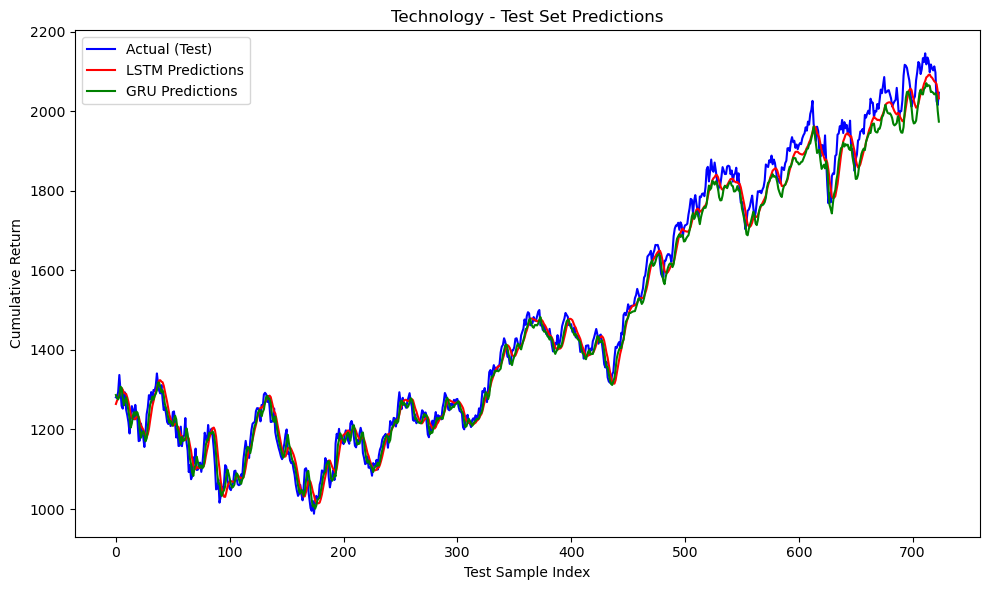

In [206]:
# LSTM predictions
pred_lstm = model_lstm.predict(X_test)

# GRU predictions
pred_gru = model_gru.predict(X_test)

pred_lstm_unscaled = scaler.inverse_transform(pred_lstm)
pred_gru_unscaled  = scaler.inverse_transform(pred_gru)

y_test_unscaled    = scaler.inverse_transform(y_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test_unscaled, label='Actual (Test)', color='blue')
plt.plot(pred_lstm_unscaled, label='LSTM Predictions', color='red')
plt.plot(pred_gru_unscaled,  label='GRU Predictions',  color='green')
plt.title(f"{sector} - Test Set Predictions")
plt.xlabel("Test Sample Index")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()


In [207]:
full_scaled = scaler.fit_transform(values)

def forecast_future(model, data_scaled, window_size=30, steps=365):
    data_scaled = data_scaled.copy()
    future_preds = []
    
    # Start with the last 'window_size' points
    input_seq = data_scaled[-window_size:].reshape(1, window_size, 1)
    
    for _ in range(steps):
        pred = model.predict(input_seq)  # shape (1,1)    
        future_preds.append(pred[0,0])
        new_val = pred[0,0].reshape(1, 1, 1)
        input_seq = np.concatenate([input_seq[:, 1:, :], new_val], axis=1)
    
    return np.array(future_preds).reshape(-1, 1)


# Forecast 2 years (730 days) with LSTM and GRU
future_lstm_scaled = forecast_future(model_lstm, full_scaled)
future_gru_scaled  = forecast_future(model_gru,  full_scaled)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

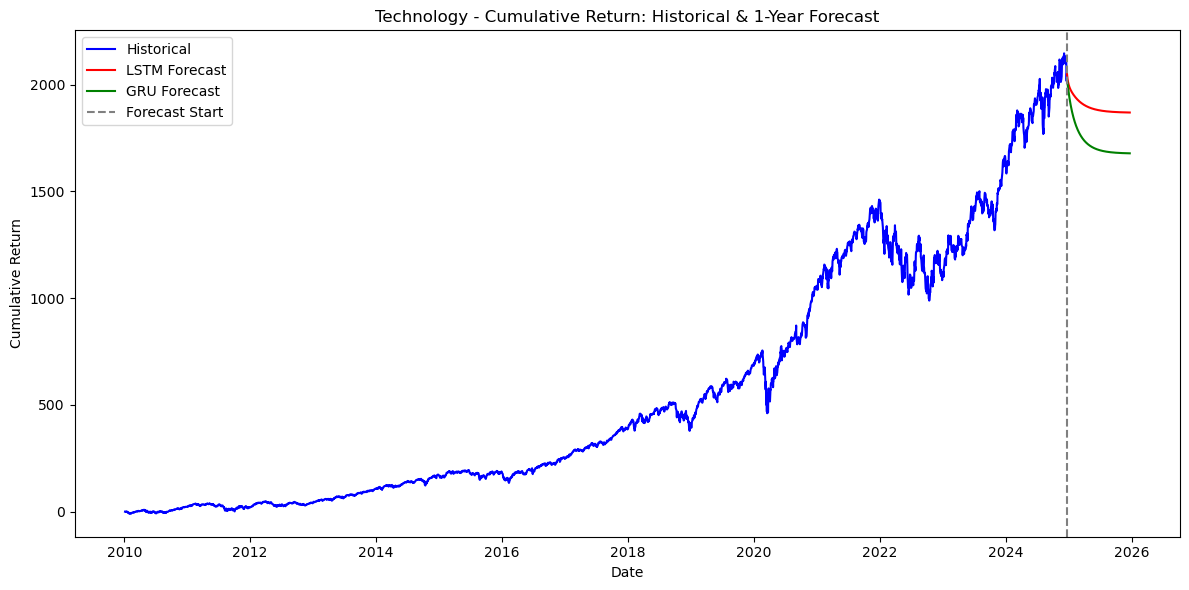

In [208]:
future_lstm = scaler.inverse_transform(future_lstm_scaled)
future_gru  = scaler.inverse_transform(future_gru_scaled)

# Last date in your historical data
last_date = series.index[-1]  # e.g. 2024-10-20

forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=365,
    freq='D'
)

# Convert to a Pandas Series for convenience
future_lstm_series = pd.Series(future_lstm.flatten(), index=forecast_dates, name='LSTM_Forecast')
future_gru_series  = pd.Series(future_gru.flatten(),  index=forecast_dates, name='GRU_Forecast')

plt.figure(figsize=(12, 6))

# Plot historical cumulative returns (entire series)
plt.plot(series.index, series.values, label='Historical', color='blue')

# Plot LSTM forecast
plt.plot(future_lstm_series.index, future_lstm_series.values, label='LSTM Forecast', color='red')

# Plot GRU forecast
plt.plot(future_gru_series.index, future_gru_series.values, label='GRU Forecast', color='green')

plt.axvline(x=last_date, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"{sector} - Cumulative Return: Historical & 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(loc="best")
plt.tight_layout()
plt.show()
